In [1]:
import numpy as np
import h5py
from transformers import AutoTokenizer
from coursework.qwen import load_qwen
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
from accelerate import Accelerator
from coursework.qwen import load_qwen
import matplotlib.pyplot as plt
import torch
import os
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import glob
import pandas as pd
from src.lora import LoRALinear

/Users/saamnazem/M2_stuff/M2_venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/saamnazem/M2_stuff/M2_venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cpu")
model, tokenizer = load_qwen()
model.to(device)

# Inject LoRA layers
lora_rank = 4
for layer in model.model.layers:
    layer.self_attn.q_proj = LoRALinear(layer.self_attn.q_proj, r=lora_rank)
    layer.self_attn.v_proj = LoRALinear(layer.self_attn.v_proj, r=lora_rank)

# Load trained LoRA weights
model.load_state_dict(torch.load("models/lora_qwen2.5_final_5000.pth", map_location="cpu"), strict=False)
model.eval()
print(model.config)

Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


Qwen2Config {
  "_attn_implementation_autoset": true,
  "_name_or_path": "Qwen/Qwen2.5-0.5B-Instruct",
  "architectures": [
    "Qwen2ForCausalLM"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "eos_token_id": 151645,
  "hidden_act": "silu",
  "hidden_size": 896,
  "initializer_range": 0.02,
  "intermediate_size": 4864,
  "max_position_embeddings": 32768,
  "max_window_layers": 21,
  "model_type": "qwen2",
  "num_attention_heads": 14,
  "num_hidden_layers": 24,
  "num_key_value_heads": 2,
  "rms_norm_eps": 1e-06,
  "rope_scaling": null,
  "rope_theta": 1000000.0,
  "sliding_window": 32768,
  "tie_word_embeddings": true,
  "torch_dtype": "float32",
  "transformers_version": "4.49.0",
  "use_cache": true,
  "use_sliding_window": false,
  "vocab_size": 151936
}



### Part 1 - FLOPS calc

In [ ]:
import h5py
with h5py.File("coursework/lotka_volterra_data.h5", "r") as f:
    print(f.keys())  


<KeysViewHDF5 ['time', 'trajectories']>


In [ ]:
# FLOP Calculation for Matrix Multiplication
def compute_matmul_flops(m, n, p):
    """
    Computes FLOPs for a matrix multiplication: (m x n) @ (n x p).
    Formula: m * p * (2n - 1)
    """
    return m * p * (2 * n - 1)

# FLOP Calculation for Self-Attention
def compute_self_attention_flops(seq_len, d_model, num_heads):
    """
    Computes FLOPs for Multi-Head Self-Attention layer.
    """
    head_dim = d_model // num_heads
    qkv_proj = 3 * compute_matmul_flops(seq_len, d_model, d_model)  # Q, K, V projections
    attention_scores = compute_matmul_flops(seq_len, head_dim, seq_len) * num_heads  # Attention dot product
    attention_output = compute_matmul_flops(seq_len, seq_len, head_dim) * num_heads  # Attention applied to values
    output_proj = compute_matmul_flops(seq_len, d_model, d_model)  # Final projection

    return qkv_proj + attention_scores + attention_output + output_proj

# FLOP Calculation for MLP (SwiGLU)
def compute_mlp_flops(seq_len, d_model, d_ffn):
    """
    Computes FLOPs for MLP block with SwiGLU activation.
    """
    gate_proj = compute_matmul_flops(seq_len, d_model, d_ffn)  # First linear projection
    activation = seq_len * d_ffn  # SwiGLU activation
    down_proj = compute_matmul_flops(seq_len, d_ffn, d_model)  # Second linear projection

    return gate_proj + activation + down_proj

# FLOP Calculation for LayerNorm
def compute_layernorm_flops(seq_len, d_model):
    """
    Computes FLOPs for LayerNorm.
    """
    return seq_len * d_model  # Element-wise ops

# Compute FLOPs for LoRA-modified Q and V projections
def compute_lora_flops(seq_len, d_model, num_heads, lora_rank):
    """
    Computes FLOPs for LoRA-modified Q and V projections.
    """
    head_dim = d_model // num_heads
    return 2 * num_heads * (2 * head_dim * lora_rank) * seq_len

# Compute Total FLOPs for One Forward Pass
def compute_forward_flops(seq_len, d_model, num_heads, d_ffn, num_layers, lora_rank):
    """
    Computes total FLOPs for a forward pass, including LoRA modifications.
    """
    total_flops = 0
    for _ in range(num_layers):
        total_flops += compute_self_attention_flops(seq_len, d_model, num_heads)
        total_flops += compute_mlp_flops(seq_len, d_model, d_ffn)
        total_flops += compute_layernorm_flops(seq_len, d_model) * 2  # 2x LayerNorm per layer
        total_flops += compute_lora_flops(seq_len, d_model, num_heads, lora_rank)  # LoRA contribution
    return total_flops

# Compute Total FLOPs for Training (Forward + Backward)
def compute_training_flops(seq_len, d_model, num_heads, d_ffn, num_layers, lora_rank, num_steps):
    """
    Computes total FLOPs for training with LoRA.
    """
    forward_flops = compute_forward_flops(seq_len, d_model, num_heads, d_ffn, num_layers, lora_rank)
    return forward_flops * 3 * num_steps  # Backprop is ~2x forward pass

# Compute Total FLOPs for Inference (Forward Only)
def compute_inference_flops(seq_len, d_model, num_heads, d_ffn, num_layers, lora_rank, num_samples):
    """
    Computes total FLOPs for inference.
    """
    return compute_forward_flops(seq_len, d_model, num_heads, d_ffn, num_layers, lora_rank) * num_samples

# Track FLOPs During Training
def track_training_flops(seq_len, d_model, num_heads, d_ffn, num_layers, lora_rank, num_steps):
    train_flops = compute_training_flops(seq_len, d_model, num_heads, d_ffn, num_layers, lora_rank, num_steps)
    print(f"Total Training FLOPs: {train_flops:.2E}")

# Track FLOPs During Inference
def track_inference_flops(seq_len, d_model, num_heads, d_ffn, num_layers, lora_rank, num_samples):
    eval_flops = compute_inference_flops(seq_len, d_model, num_heads, d_ffn, num_layers, lora_rank, num_samples)
    print(f"Total Inference FLOPs: {eval_flops:.2E}")

In [ ]:
# Define your model settings
configs = [
    {"model_name": "3c_4", "hidden_dim": 896, "seq_len": 256, "num_layers": 24, "lora_rank": 8, "steps": 6000, "num_heads": 14, "d_ffn": 4864},
    {"model_name": "3c_3", "hidden_dim": 896, "seq_len": 256, "num_layers": 24, "lora_rank": 8, "steps": 12000, "num_heads": 14, "d_ffn": 4864},
    {"model_name": "5000", "hidden_dim": 896, "seq_len": 256, "num_layers": 24, "lora_rank": 4, "steps": 5000, "num_heads": 14, "d_ffn": 4864},
    {"model_name": "lr0.0001_rank2", "hidden_dim": 896, "seq_len": 256, "num_layers": 24, "lora_rank": 2, "steps": 500, "num_heads": 14, "d_ffn": 4864},
    {"model_name": "lr0.0001_rank4", "hidden_dim": 896, "seq_len": 256, "num_layers": 24, "lora_rank": 4, "steps": 500, "num_heads": 14, "d_ffn": 4864},
    {"model_name": "lr0.0001_rank8", "hidden_dim": 896, "seq_len": 256, "num_layers": 24, "lora_rank": 8, "steps": 500, "num_heads": 14, "d_ffn": 4864},
    {"model_name": "lr1e-05_rank2", "hidden_dim": 896, "seq_len": 256, "num_layers": 24, "lora_rank": 2, "steps": 500, "num_heads": 14, "d_ffn": 4864},
    {"model_name": "lr1e-05_rank4", "hidden_dim": 896, "seq_len": 256, "num_layers": 24, "lora_rank": 4, "steps": 500, "num_heads": 14, "d_ffn": 4864},
    {"model_name": "lr1e-05_rank8", "hidden_dim": 896, "seq_len": 256, "num_layers": 24, "lora_rank": 8, "steps": 500, "num_heads": 14, "d_ffn": 4864},   
    {"model_name": "lr5e-05_rank2", "hidden_dim": 896, "seq_len": 256, "num_layers": 24, "lora_rank": 2, "steps": 500, "num_heads": 14, "d_ffn": 4864},
    {"model_name": "lr5e-05_rank4", "hidden_dim": 896, "seq_len": 256, "num_layers": 24, "lora_rank": 4, "steps": 500, "num_heads": 14, "d_ffn": 4864},
    {"model_name": "lr5e-05_rank8", "hidden_dim": 896, "seq_len": 256, "num_layers": 24, "lora_rank": 8, "steps": 500, "num_heads": 14, "d_ffn": 4864},
    {"model_name": "lr0.001_rank8_128", "hidden_dim": 896, "seq_len": 128, "num_layers": 24, "lora_rank": 8, "steps": 400, "num_heads": 14, "d_ffn": 4864},
    {"model_name": "lr0.001_rank8_512", "hidden_dim": 896, "seq_len": 512, "num_layers": 24, "lora_rank": 8, "steps": 400, "num_heads": 14, "d_ffn": 4864},
    {"model_name": "lr0.001_rank8_768", "hidden_dim": 896, "seq_len": 768, "num_layers": 24, "lora_rank": 8, "steps": 400, "num_heads": 14, "d_ffn": 4864},

]

# Compute FLOPS for each model
flops_per_model = {}
for config in configs:
    key = f"Model_name={config['model_name']}, Seq={config['seq_len']}, Layers={config['num_layers']}, steps={config['steps']}, LoRA={config['lora_rank']}"
    flops_per_model[key] = compute_training_flops(
        seq_len=config['seq_len'],
        d_model=config['hidden_dim'],
        num_heads=config['num_heads'],
        d_ffn=config['d_ffn'],
        num_layers=config['num_layers'],
        lora_rank=config['lora_rank'],
        num_steps=config['steps']
    )

for model, flops in flops_per_model.items():
    print(f"Model {model}: {flops:.2e} FLOPS")

Model Model_name=3c_4, Seq=256, Layers=24, steps=6000, LoRA=8: 2.74e+15 FLOPS
Model Model_name=3c_3, Seq=256, Layers=24, steps=12000, LoRA=8: 5.48e+15 FLOPS
Model Model_name=5000, Seq=256, Layers=24, steps=5000, LoRA=4: 2.28e+15 FLOPS
Model Model_name=lr0.0001_rank2, Seq=256, Layers=24, steps=500, LoRA=2: 2.28e+14 FLOPS
Model Model_name=lr0.0001_rank4, Seq=256, Layers=24, steps=500, LoRA=4: 2.28e+14 FLOPS
Model Model_name=lr0.0001_rank8, Seq=256, Layers=24, steps=500, LoRA=8: 2.29e+14 FLOPS
Model Model_name=lr1e-05_rank2, Seq=256, Layers=24, steps=500, LoRA=2: 2.28e+14 FLOPS
Model Model_name=lr1e-05_rank4, Seq=256, Layers=24, steps=500, LoRA=4: 2.28e+14 FLOPS
Model Model_name=lr1e-05_rank8, Seq=256, Layers=24, steps=500, LoRA=8: 2.29e+14 FLOPS
Model Model_name=lr5e-05_rank2, Seq=256, Layers=24, steps=500, LoRA=2: 2.28e+14 FLOPS
Model Model_name=lr5e-05_rank4, Seq=256, Layers=24, steps=500, LoRA=4: 2.28e+14 FLOPS
Model Model_name=lr5e-05_rank8, Seq=256, Layers=24, steps=500, LoRA=8: 2.2

In [34]:
flops_gen_untrained = compute_inference_flops(seq_len=256, d_model=896, num_heads=14, d_ffn=4864, num_layers=24, lora_rank=0, num_samples=800)
print(f"FLOPs for untrained model: {flops_gen_untrained:.2e}")

FLOPs for untrained model: 1.22e+14


### Part 2 - LLTIME

In [ ]:
class LLMTIMEPreprocessor:
    def __init__(self, scale_factor=10, decimal_places=2, model_name="Qwen/Qwen2.5-0.5B-Instruct"):
        """
        Initialize LLMTIME Preprocessor.

        :param scale_factor: Factor to scale numeric values before rounding.
        :param decimal_places: Number of decimal places to round to.
        :param model_name: HuggingFace model name for tokenization.
        """
        self.scale_factor = scale_factor
        self.decimal_places = decimal_places
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)

    def preprocess_sequence(self, sequence):
        """
        Preprocesses a single time series sequence for LLMTIME tokenization.

        :param sequence: np.array of shape (time_steps, 2) where:
                         - [:,0] = Prey population
                         - [:,1] = Predator population
        :return: Preprocessed string representation.
        """
        scaled = sequence / self.scale_factor
        rounded = np.round(scaled, self.decimal_places)

        # Convert to string format: "x1,y1; x2,y2; ..."
        formatted_sequence = ";".join([",".join(map(str, row)) for row in rounded])
        return formatted_sequence

    def tokenize_sequence(self, sequence_str):
        """
        Tokenizes a preprocessed time series string using Qwen tokenizer.

        :param sequence_str: Preprocessed LLMTIME-formatted string.
        :return: List of token IDs.
        """
        tokens = self.tokenizer(sequence_str, return_tensors="pt")["input_ids"].tolist()[0]
        return tokens



def load_and_preprocess(filename="coursework/lotka_volterra_data.h5", num_systems=100, time_steps=20, fraction=0.5):
    """
    Loads multiple time series from the dataset and preprocesses them.

    :param filename: Path to HDF5 dataset.
    :param num_systems: Number of systems to load.
    :param time_steps: Number of timesteps per system.
    :return: Tuple (train_texts, val_texts)
    """
    with h5py.File(filename, "r") as f:
        trajectories = f["trajectories"][:]

    # Initialize Preprocessor
    preprocessor = LLMTIMEPreprocessor()

    all_sequences = []
    for i in range(min(num_systems, len(trajectories))):
        sequence = trajectories[i, :time_steps, :]
        preprocessed_seq = preprocessor.preprocess_sequence(sequence)
        all_sequences.append(preprocessed_seq)

    # Split into train and validation sets (80% train, 20% val)
    split_idx = int(fraction * len(all_sequences))
    train_texts = all_sequences[:split_idx]
    val_texts = all_sequences[split_idx:]

    return train_texts, val_texts




def load_sample_data(filename="coursework/lotka_volterra_data.h5", system_id=0, time_steps=10):
    """
    Loads a sample time series from the dataset.

    :param filename: Path to HDF5 dataset.
    :param system_id: ID of the system to sample.
    :param time_steps: Number of timesteps to extract.
    :return: np.array of shape (time_steps, 2).
    """
    with h5py.File(filename, "r") as f:
        trajectories = f["trajectories"][:]
    return trajectories[system_id, :time_steps, :]

if __name__ == "__main__":
    # Load sample data
    sample_data = load_sample_data(time_steps=100)

    # Initialize preprocessor
    preprocessor = LLMTIMEPreprocessor()

    # Process and tokenize the sequence
    preprocessed_seq = preprocessor.preprocess_sequence(sample_data)
    tokenized_seq = preprocessor.tokenize_sequence(preprocessed_seq)

    # Print results
    print("\n🔹 Preprocessed Sequence:")
    print(preprocessed_seq)
    print("\n🔹 Tokenized Sequence:")
    print(tokenized_seq)


def load_sample_data2(filename="coursework/lotka_volterra_data.h5", system_id=0, time_steps=10):
    with h5py.File(filename, "r") as f:
        trajectories = f["trajectories"][:]
        time_points = f["time"][:]
        system_id = 0 
        prey = trajectories[0, :50, 0]
        predator = trajectories[0, :50, 1]
        times = time_points[:50]

    return prey, predator, times


if __name__ == "__main__":
    prey, predator, times = load_sample_data2()

    print(f"Prey Population: {prey}")
    print(f"Predator Population: {predator}")
    print(f"Time Points: {times}")


🔹 Preprocessed Sequence:
0.09,0.1;0.07,0.08;0.07,0.06;0.07,0.04;0.08,0.03;0.1,0.02;0.13,0.02;0.16,0.02;0.2,0.02;0.25,0.02;0.3,0.02;0.35,0.02;0.39,0.03;0.4,0.05;0.38,0.06;0.33,0.08;0.26,0.1;0.19,0.1;0.14,0.09;0.11,0.08;0.1,0.06;0.1,0.05;0.11,0.04;0.13,0.03;0.15,0.03;0.18,0.02;0.21,0.02;0.25,0.03;0.28,0.03;0.31,0.03;0.33,0.04;0.33,0.05;0.3,0.07;0.26,0.08;0.22,0.08;0.18,0.08;0.15,0.08;0.13,0.07;0.13,0.06;0.13,0.05;0.14,0.04;0.16,0.04;0.18,0.03;0.2,0.03;0.23,0.03;0.25,0.03;0.28,0.04;0.29,0.05;0.29,0.05;0.27,0.06;0.25,0.07;0.22,0.07;0.19,0.07;0.17,0.07;0.15,0.06;0.15,0.06;0.15,0.05;0.15,0.04;0.17,0.04;0.18,0.04;0.2,0.04;0.22,0.04;0.24,0.04;0.25,0.04;0.26,0.05;0.26,0.05;0.25,0.06;0.24,0.06;0.22,0.07;0.2,0.07;0.18,0.07;0.17,0.06;0.16,0.06;0.16,0.05;0.17,0.05;0.18,0.04;0.19,0.04;0.2,0.04;0.22,0.04;0.23,0.04;0.24,0.05;0.25,0.05;0.25,0.05;0.24,0.06;0.23,0.06;0.21,0.06;0.2,0.06;0.19,0.06;0.18,0.06;0.17,0.06;0.17,0.05;0.18,0.05;0.18,0.05;0.19,0.04;0.2,0.04;0.22,0.04;0.22,0.05;0.23,0.05;0.24,0.05;

In [ ]:
import re

system_id = 850 
device = torch.device("cpu")
model_q, tokenizer = load_qwen()  

model_q.to(device)
model_q.eval()

# Define parameters
time_steps = 100
forecast_horizon = 40 # Predict 1 time steps (10 values)
history_length = time_steps - forecast_horizon  # Model sees 5 time steps (10 values)

preprocessor = LLMTIMEPreprocessor()
sample_data = load_sample_data(system_id=system_id, time_steps=time_steps)  # Shape: (10,2)

sample_data_train = sample_data[:history_length]  # (5,2) → 5 time steps
sample_data_val = sample_data[history_length:history_length+forecast_horizon]  # (5,2) → 5 time steps

preprocessed_seq = preprocessor.preprocess_sequence(sample_data_train)  
tokenized_seq = preprocessor.tokenize_sequence(preprocessed_seq)

# Convert tokenized sequence into tensor
encoded_input = tokenizer(preprocessed_seq, return_tensors="pt", padding=True, truncation=True)
input_ids = encoded_input["input_ids"].to(device)
attention_mask = encoded_input["attention_mask"].to(device)

# Generate extra tokens (to ensure enough numbers are extracted)
with torch.no_grad():
    output = model_q.generate(
        input_ids,
        attention_mask=attention_mask,
        max_new_tokens=10 * forecast_horizon * 2,
        min_length=forecast_horizon * 10,
    )

# Decode model output
decoded_output = tokenizer.decode(output[0], skip_special_tokens=True)

######### Extract numerical values from model output
# def extract_numerical_values(decoded_text):
#     """Extract numerical values from model-generated text."""
#     numeric_strings = decoded_text.replace(";", ",").split(",")  # Handle formatting
#     print("Raw Extracted Strings:", numeric_strings)
#     return np.array([float(x) for x in numeric_strings[:-5]])


def extract_numerical_values(decoded_text):
    """
    Extracts numerical float values from the decoded model output using regex.
    Filters out non-numeric noise and malformed values.
    """
    matches = re.findall(r"\d*\.\d+|\d+", decoded_text)
    print(f"🧐 Extracted {len(matches)} numeric values")
    print("🔍 Extracted Matches:", matches)
    return np.array([float(x) for x in matches])


# Get only first 80 (forecast_horizon * 2) predicted values
predicted_values = extract_numerical_values(decoded_output)[:forecast_horizon * 2] * 10
predicted_values_full = extract_numerical_values(decoded_output) * 10

# Match with true values
true_values = sample_data_val.flatten()[:len(predicted_values)]
# # Extract numerical values (ensure exactly 10)
# predicted_values_full = extract_numerical_values(decoded_output) * 10

# start_index = len(sample_data_train.flatten())
# end_index = start_index + (forecast_horizon * 2)

# # Extract the correctly aligned predictions
# predicted_values = predicted_values_full[start_index:end_index]  

# # Ensure true values are correctly extracted
# true_values = sample_data_val.flatten()[:len(predicted_values)]  

print(f"🔹 True Values Length: {len(true_values)}, Predicted Values Length: {len(predicted_values)}")


print(f'lenght of decoded_output: {len(decoded_output)}')
print(f'Length tokenized sequence: {len(tokenized_seq)}')
print(f'Length true values: {len(true_values)}')  # Should be 10
print(f'Length predicted values: {len(predicted_values)}')  # Should be 10

# Evaluate predictions only if we got exactly 10 values
if len(predicted_values) == forecast_horizon * 2:
    mse = mean_squared_error(true_values, predicted_values)
    mae = mean_absolute_error(true_values, predicted_values)
    r2 = r2_score(true_values, predicted_values)
else:
    mse, mae, r2 = np.nan, np.nan, np.nan  # Model didn't generate valid predictions

# Print results
print("\n🔹 Decoded Model Output:\n", decoded_output)
print("\n🔹 True Next 5 Values:\n", true_values)
print("\n🔹 Predicted Next 5 Values:\n", predicted_values)
print(f"\n🔹 Evaluation Metrics:\nMSE: {mse:.5f} | MAE: {mae:.5f} | R² Score: {r2:.5f}")

🧐 Extracted 297 numeric values
🔍 Extracted Matches: ['0.12', '0.09', '0.13', '0.08', '0.15', '0.07', '0.18', '0.07', '0.21', '0.07', '0.25', '0.07', '0.27', '0.08', '0.29', '0.09', '0.3', '0.1', '0.3', '0.11', '0.28', '0.12', '0.25', '0.14', '0.22', '0.14', '0.19', '0.14', '0.17', '0.14', '0.15', '0.13', '0.14', '0.12', '0.14', '0.11', '0.14', '0.1', '0.15', '0.09', '0.17', '0.09', '0.18', '0.09', '0.2', '0.08', '0.22', '0.09', '0.24', '0.09', '0.25', '0.09', '0.26', '0.1', '0.25', '0.11', '0.25', '0.12', '0.23', '0.12', '0.22', '0.13', '0.2', '0.13', '0.19', '0.13', '0.17', '0.12', '0.17', '0.12', '0.16', '0.11', '0.17', '0.11', '0.17', '0.1', '0.18', '0.1', '0.19', '0.1', '0.2', '0.09', '0.21', '0.09', '0.22', '0.1', '0.23', '0.1', '0.23', '0.1', '0.23', '0.11', '0.23', '0.11', '0.22', '0.11', '0.21', '0.12', '0.2', '0.12', '0.19', '0.12', '0.19', '0.12', '0.18', '0.11', '0.18', '0.11', '0.18', '0.11', '0.18', '0.1', '0.19', '0.1', '0.19', '0.1', '0.2', '0.1', '0.2', '0.1', '0.19', '

/Users/saamnazem/M2_stuff/M2_venv/lib/python3.9/site-packages/transformers/generation/configuration_utils.py:629: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/Users/saamnazem/M2_stuff/M2_venv/lib/python3.9/site-packages/transformers/generation/configuration_utils.py:634: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/Users/saamnazem/M2_stuff/M2_venv/lib/python3.9/site-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


🧐 Extracted 180 numeric values
🧐 Extracted 180 numeric values

🔹 Forecast Metrics:
MSE = 0.15841 | MAE = 0.31428 | R² = 0.30364


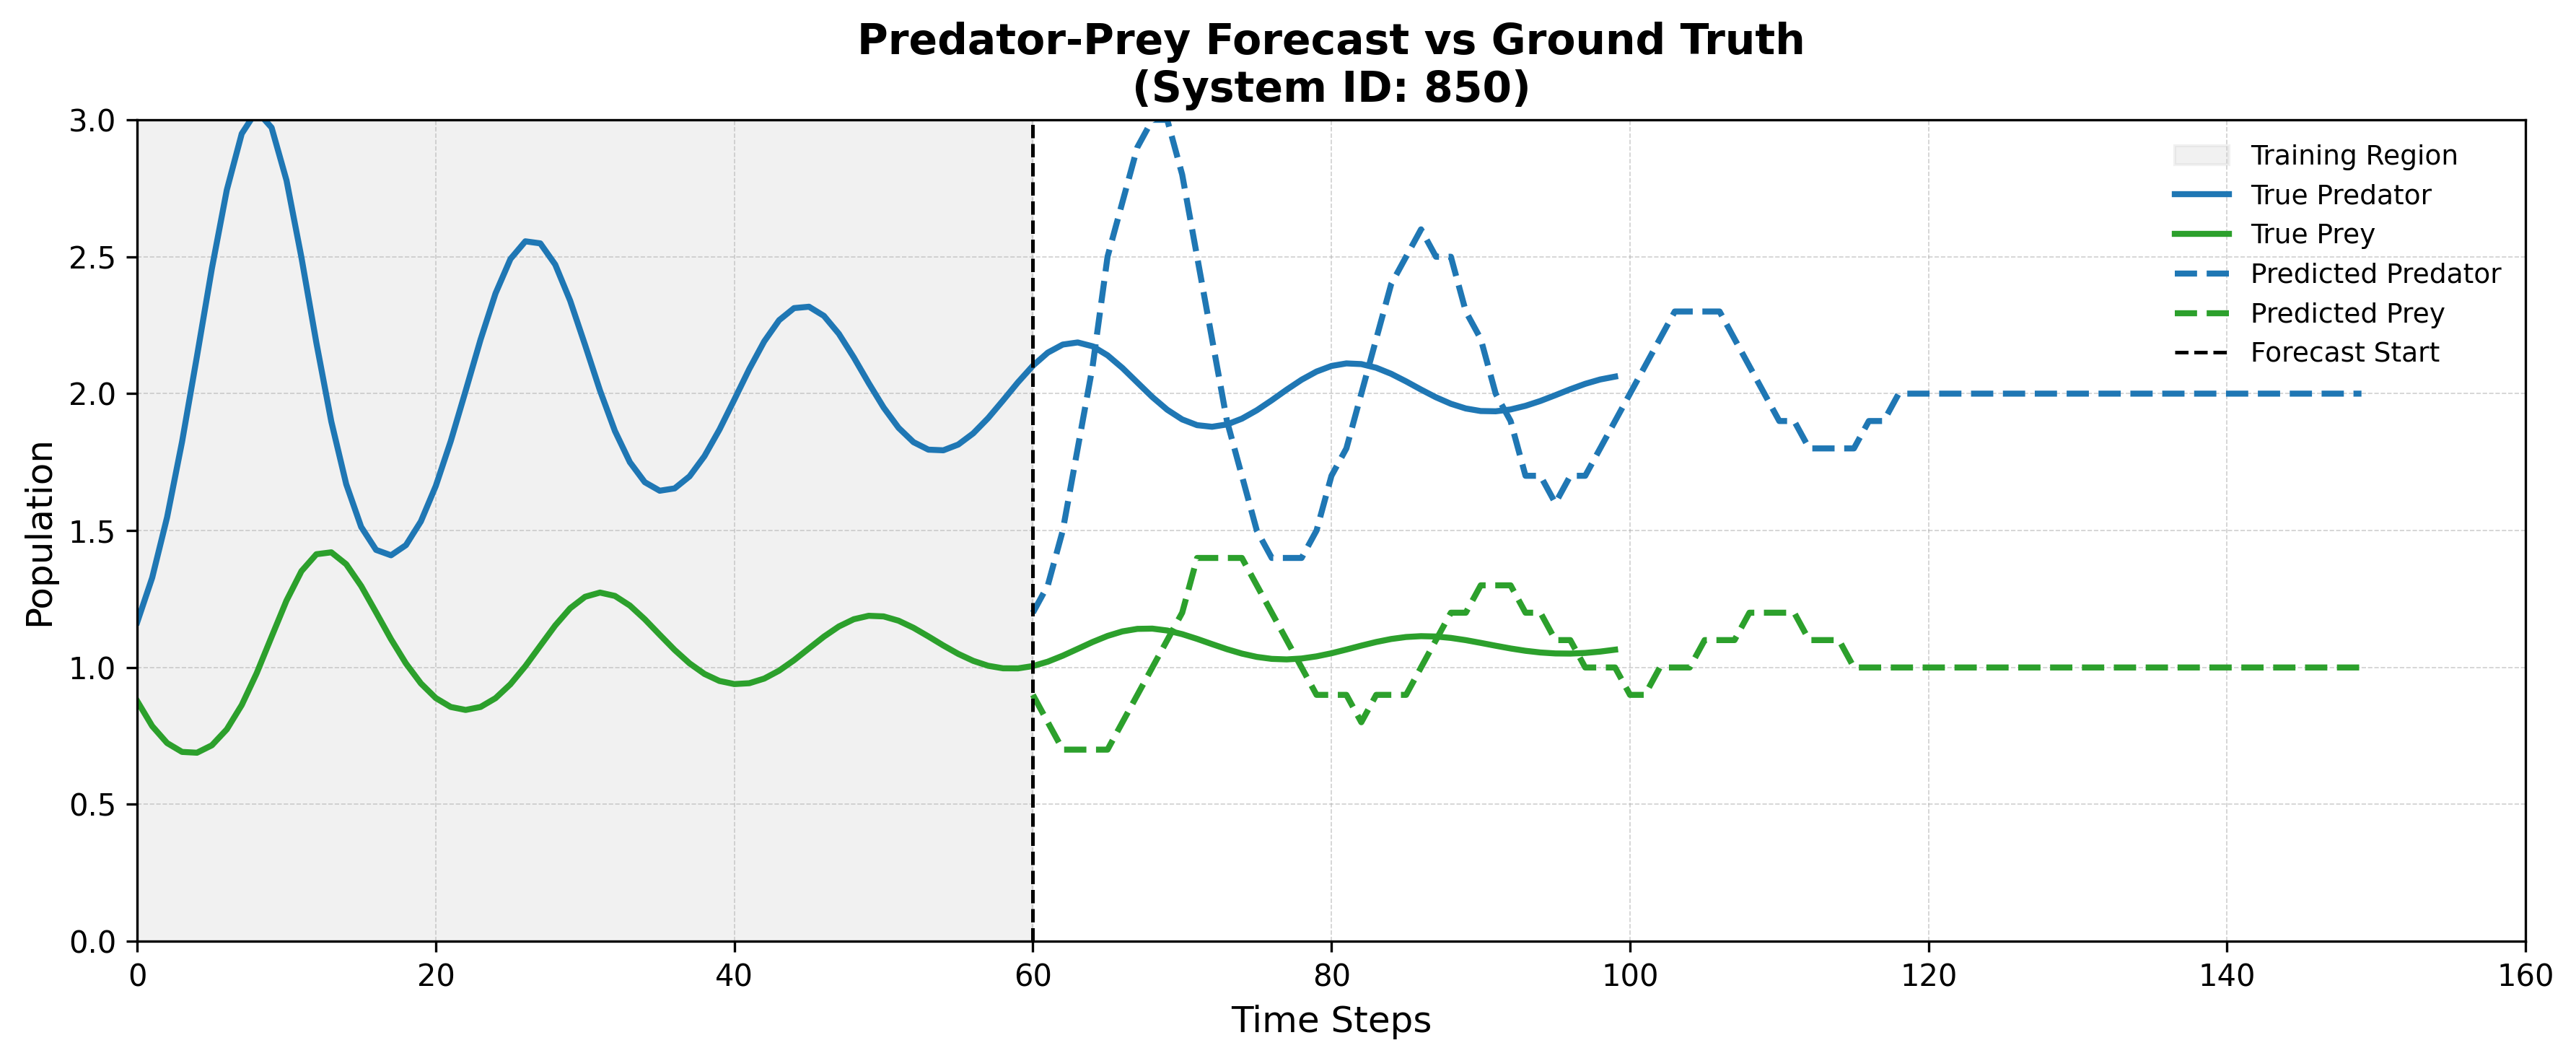

In [ ]:
import re
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt


model, tokenizer = load_qwen()


# ──────────────────────
# 0. Parameters
# ──────────────────────

system_id = 850  # or any other system ID you want to evaluate
time_steps = 100
forecast_horizon = 40  # Predict final 40 steps (80 values since dim=2)
history_length = time_steps - forecast_horizon  # First 60 steps = training

# ──────────────────────
# 1. Load raw system data
# ──────────────────────

preprocessor = LLMTIMEPreprocessor()
sample_data = load_sample_data(system_id=system_id, time_steps=time_steps)  # Shape: (time_steps, 2)

# ──────────────────────
# 2. Train/Val split
# ──────────────────────

sample_data_train = sample_data[:history_length]        # (60, 2) for model input
sample_data_val = sample_data[history_length:]          # (40, 2) for evaluation

# ──────────────────────
# 3. Preprocess for LLM (from array → natural language format)
# ──────────────────────

preprocessed_seq = preprocessor.preprocess_sequence(sample_data_train)  
# e.g., "Prey: 0.81, Predator: 0.92; Prey: 0.67, Predator: 0.81; ..."

# ──────────────────────
# 4. Tokenize the input sequence
# ──────────────────────

encoded_input = tokenizer(preprocessed_seq, return_tensors="pt", padding=True, truncation=True)
input_ids = encoded_input["input_ids"].to(device)
attention_mask = encoded_input["attention_mask"].to(device)


# ──────────────────────
# Forecast with model
# ──────────────────────
with torch.no_grad():
    output = model.generate(
        input_ids,
        attention_mask=attention_mask,
        max_new_tokens=forecast_horizon * 2 * 3,
        do_sample=False,
        eos_token_id=tokenizer.eos_token_id,
    )

decoded_output = tokenizer.decode(output[0], skip_special_tokens=True)

# ──────────────────────
# Extract values
# ──────────────────────
def extract_numerical_values(decoded_text):
    matches = re.findall(r"\d*\.\d+|\d+", decoded_text)
    print(f"Extracted {len(matches)} numeric values")
    return np.array([float(x) for x in matches])

predicted_values = extract_numerical_values(decoded_output)[:forecast_horizon * 2] * 10
predicted_values_full = extract_numerical_values(decoded_output) * 10

# ──────────────────────
# Evaluation
# ──────────────────────
true_values = sample_data_val.flatten()[:len(predicted_values)]

if len(predicted_values) == len(true_values):
    mse = mean_squared_error(true_values, predicted_values)
    mae = mean_absolute_error(true_values, predicted_values)
    r2 = r2_score(true_values, predicted_values)
else:
    mse = mae = r2 = np.nan

print(f"\n🔹 Forecast Metrics:\nMSE = {mse:.5f} | MAE = {mae:.5f} | R² = {r2:.5f}")

# ──────────────────────
# Plotting block
# ──────────────────────

# Flatten full ground truth (train + val)
full_true_values = np.append(sample_data_train.flatten(), sample_data_val.flatten())

# Define predator = even, prey = odd (double check your convention!)
full_true_predator = full_true_values[::2]
full_true_prey = full_true_values[1::2]

true_predator = true_values[::2]
true_prey = true_values[1::2]

predicted_predator = predicted_values_full[::2]
predicted_prey = predicted_values_full[1::2]

# Time axes
time_true = np.arange(len(full_true_prey))
time_predicted = np.arange(60, 60 + len(predicted_predator))  # or predicted_prey

# Clip prediction for visual clarity
n_pred_to_plot = min(len(predicted_predator), 100)
n_prey_to_plot = min(len(predicted_prey), 100)
predicted_predator_clipped = predicted_predator[:n_pred_to_plot]
predicted_prey_clipped = predicted_prey[:n_prey_to_plot]
time_predicted_clipped_pred = time_predicted[:n_pred_to_plot]
time_predicted_clipped_prey = time_predicted[:n_prey_to_plot]

plt.figure(figsize=(12, 5), dpi=300)

# Color scheme
true_predator_color = '#1f77b4'
pred_predator_color = '#1f77b4'
true_prey_color = '#2ca02c'
pred_prey_color = '#2ca02c'

# Shade training region
plt.axvspan(0, 60, color='lightgrey', alpha=0.3, label="Training Region")

# Plot true
plt.plot(time_true, full_true_predator, label="True Predator", linestyle='-', color=true_predator_color, linewidth=2)
plt.plot(time_true, full_true_prey, label="True Prey", linestyle='-', color=true_prey_color, linewidth=2)

# Plot predicted
plt.plot(time_predicted_clipped_pred, predicted_predator_clipped, label="Predicted Predator", linestyle='--', color=pred_predator_color, linewidth=2)
plt.plot(time_predicted_clipped_prey, predicted_prey_clipped, label="Predicted Prey", linestyle='--', color=pred_prey_color, linewidth=2)

# Forecast start
plt.axvline(x=60, color='black', linestyle='--', lw=1.2, label="Forecast Start")

# Labels and style
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Population", fontsize=12)
plt.title(f"Predator-Prey Forecast vs Ground Truth\n(System ID: {system_id})", fontsize=14, weight='bold')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(0, 160)
plt.ylim(0, 3)
plt.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)
plt.legend(fontsize=9, loc='upper right', frameon=False)
plt.tight_layout()
plt.show()


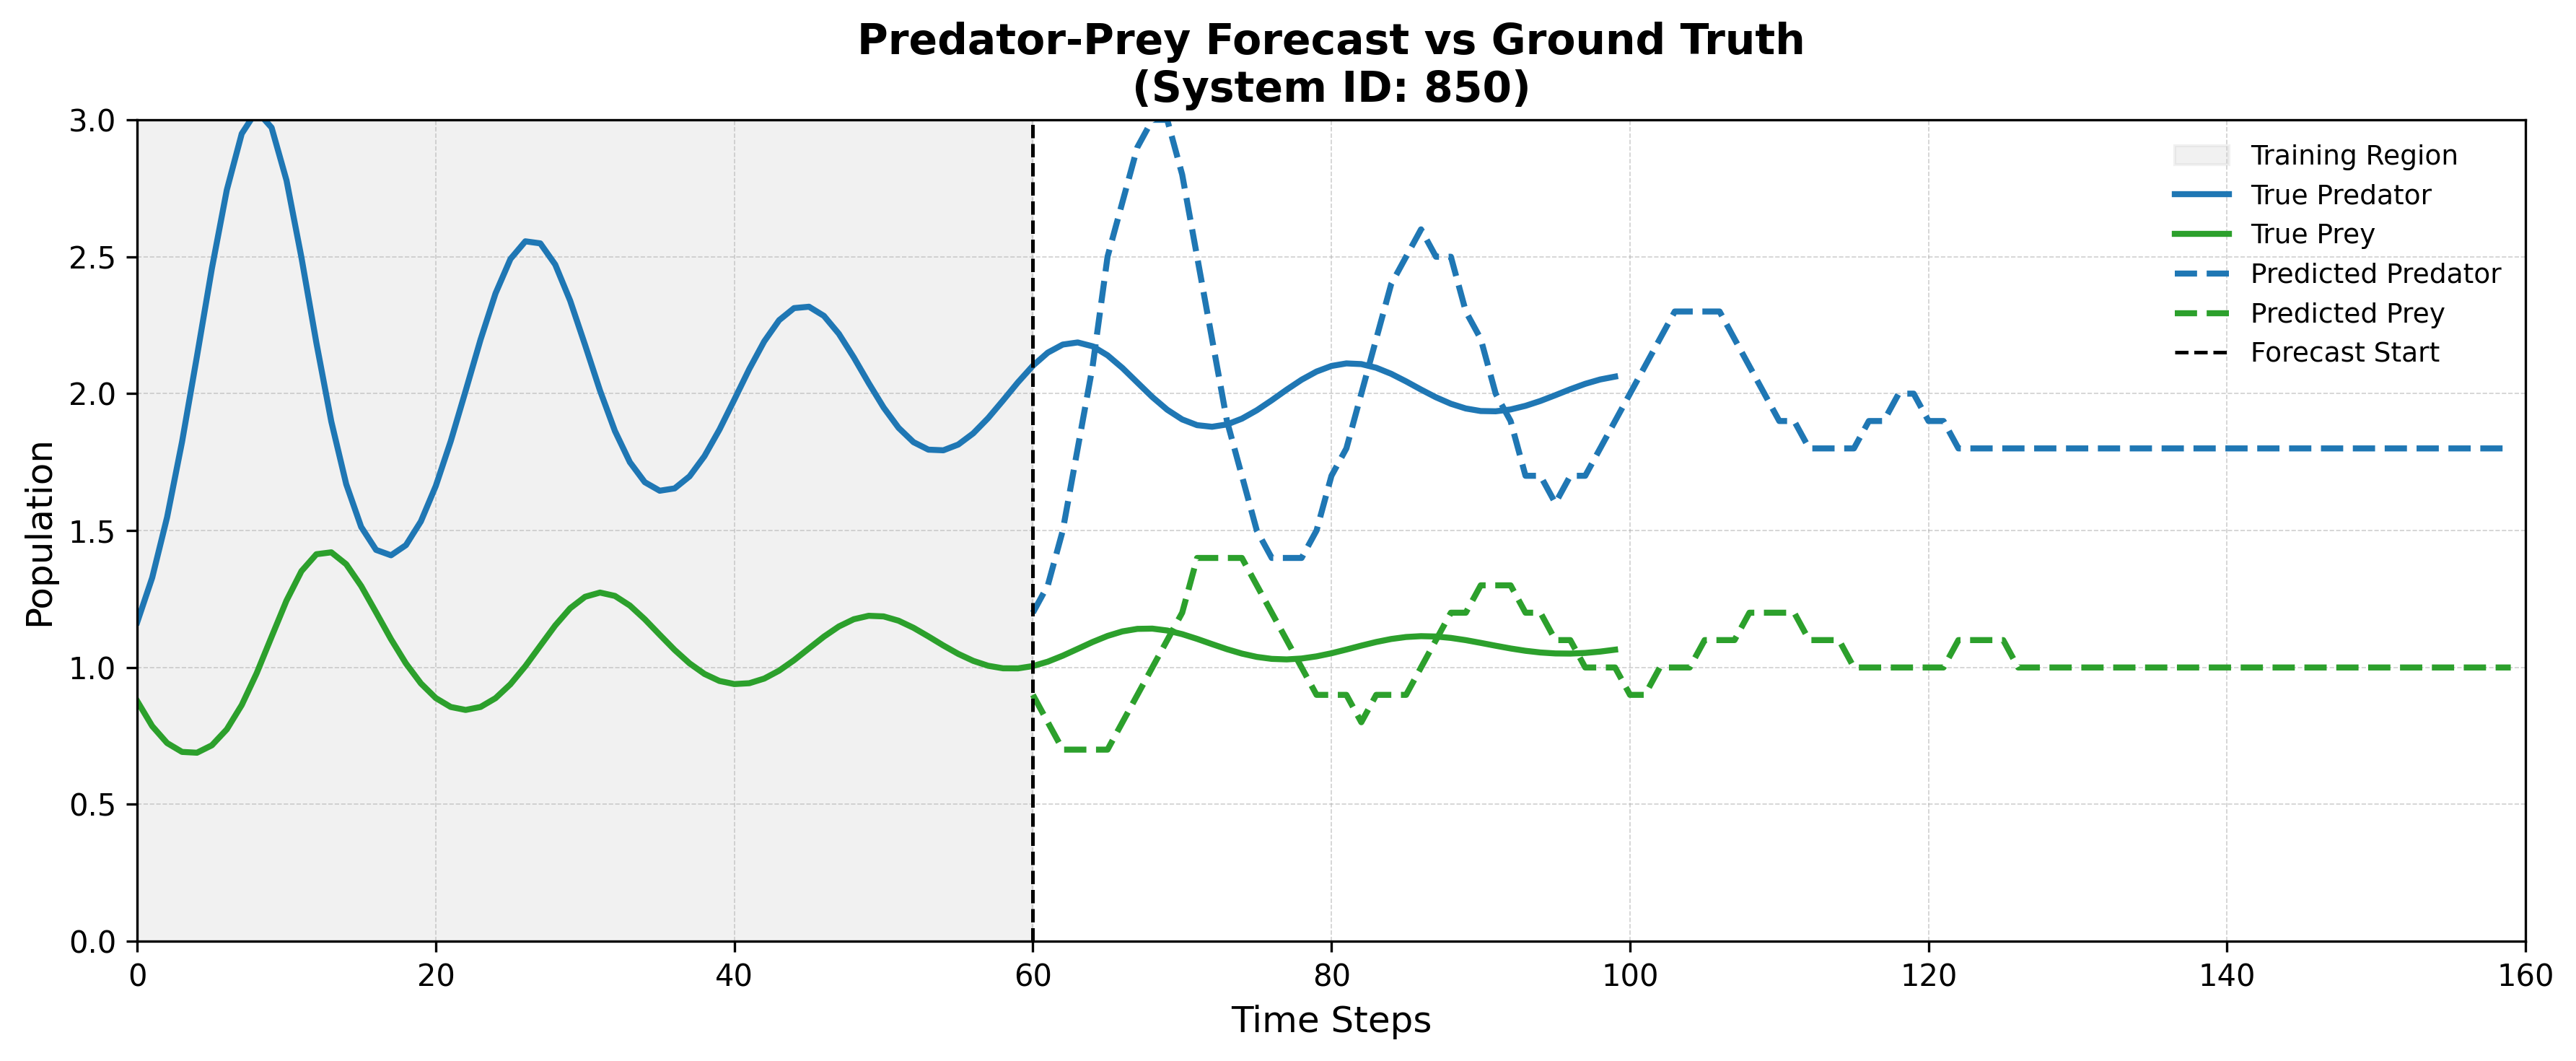

In [36]:
# Flatten full ground truth (train + val)
full_true_values = np.append(sample_data_train.flatten(), sample_data_val.flatten())

# Make sure to consistently define even = prey, odd = predator (adjust if needed)
full_true_predator = full_true_values[::2]
full_true_prey = full_true_values[1::2]

true_predator = true_values[::2]
true_prey = true_values[1::2]

predicted_predator = predicted_values_full[::2]
predicted_prey = predicted_values_full[1::2]

# Time axes
time_true = np.arange(len(full_true_prey))
time_pred = np.arange(len(predicted_prey))

time_predicted = np.arange(60, 60 + len(predicted_predator))  # or predicted_prey

n_pred_to_plot = min(len(predicted_predator), 100)

predicted_predator_clipped = predicted_predator[:n_pred_to_plot]
predicted_prey_clipped = predicted_prey[:n_pred_to_plot]
time_predicted_clipped = time_predicted[:n_pred_to_plot]

plt.figure(figsize=(12, 5), dpi=300)

# Define color scheme
true_predator_color = '#1f77b4'     # dark blue
pred_predator_color = '#1f77b4'     # same blue

true_prey_color = '#2ca02c'         # dark green
pred_prey_color = '#2ca02c'         

# Shade training region
plt.axvspan(0, 60, color='lightgrey', alpha=0.3, label="Training Region")

# Plot true values
plt.plot(time_true, full_true_predator, label="True Predator", linestyle='-', color=true_predator_color, linewidth=2)
plt.plot(time_true, full_true_prey, label="True Prey", linestyle='-', color=true_prey_color, linewidth=2)

# Plot predicted values
plt.plot(time_predicted_clipped, predicted_predator_clipped, label="Predicted Predator", linestyle='--', color=pred_predator_color, linewidth=2)
plt.plot(time_predicted_clipped, predicted_prey_clipped, label="Predicted Prey", linestyle='--', color=pred_prey_color, linewidth=2)

# Forecast start marker
plt.axvline(x=60, color='black', linestyle='--', lw=1.2, label="Forecast Start")

# Labels and layout
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Population", fontsize=12)
plt.title(f"Predator-Prey Forecast vs Ground Truth\n(System ID: {system_id})", fontsize=14, weight='bold')

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(0, 160)
plt.ylim(0, 3)
plt.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)
plt.legend(fontsize=9, loc='upper right', frameon=False)

plt.tight_layout()
plt.show()



### Part 3 - LoR


In [ ]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "0"
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "" 
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "0" 

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
from accelerate import Accelerator
from coursework.qwen import load_qwen

# Force everything to CPU
device = torch.device("cpu")

# Load model and move to CPU
model, tokenizer = load_qwen()
model.to(device)

# LoRA Implementation
class LoRALinear(nn.Module):
    def __init__(self, original_linear: nn.Linear, r: int, alpha: int = None):
        super().__init__()
        assert isinstance(original_linear, nn.Linear)
        self.original_linear = original_linear
        self.original_linear.weight.requires_grad = False
        if self.original_linear.bias is not None:
            self.original_linear.bias.requires_grad = False

        in_dim = original_linear.in_features
        out_dim = original_linear.out_features
        self.r = r
        self.alpha = alpha if alpha else r

        device = original_linear.weight.device
        self.A = nn.Parameter(torch.empty(r, in_dim, device=device))
        self.B = nn.Parameter(torch.zeros(out_dim, r, device=device))  # Fixed initialization

        # Use He initialization for A
        nn.init.kaiming_normal_(self.A, nonlinearity="linear")

    def forward(self, x):
        base_out = self.original_linear(x)
        lora_out = (x @ self.A.T) @ self.B.T
        return base_out + lora_out * (self.alpha / self.r)

# Apply LoRA to Query & Value Projection Layers
lora_rank = 4
for layer in model.model.layers:
    layer.self_attn.q_proj = LoRALinear(layer.self_attn.q_proj, r=lora_rank) 
    layer.self_attn.v_proj = LoRALinear(layer.self_attn.v_proj, r=lora_rank)

# Load dataset
train_texts, val_texts = load_and_preprocess("coursework/lotka_volterra_data.h5", num_systems=100, time_steps=10, fraction=0.8)  # Ensure correct dataset loading

# Tokenize dataset with sliding windows
def process_sequences(texts, tokenizer, max_length=512, stride=256):  # Fixed max_length & stride
    all_input_ids = []
    for text in texts:
        encoding = tokenizer(text, return_tensors="pt", add_special_tokens=False)
        seq_ids = encoding.input_ids[0]  

        for i in range(0, len(seq_ids), stride):
            chunk = seq_ids[i : i + max_length]
            if len(chunk) < max_length:
                chunk = torch.cat([chunk, torch.full((max_length - len(chunk),), tokenizer.pad_token_id)])
            all_input_ids.append(chunk)
    
    return torch.stack(all_input_ids)

# Set optimized training settings
max_ctx_length = 256  
batch_size = 2  
learning_rate = 1e-5

# Convert tokenized text into tensors
train_input_ids = process_sequences(train_texts, tokenizer, max_ctx_length)
val_input_ids = process_sequences(val_texts, tokenizer, max_ctx_length)

# Prepare DataLoaders
train_dataset = TensorDataset(train_input_ids)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(val_input_ids)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

# Optimizer (only trainable LoRA parameters)
optimizer = torch.optim.Adam((p for p in model.parameters() if p.requires_grad), lr=learning_rate)

# Use Accelerator for efficient training
accelerator = Accelerator()
model, optimizer, train_loader = accelerator.prepare(model, optimizer, train_loader)

train_losses = []
val_losses = []
true_series = []
predicted_series = []
eval_interval = 100  # Evaluate validation loss every 100 steps

for param in model.parameters():
    param.data = param.data.to("cpu")
    if param.grad is not None:
        param.grad.data = param.grad.data.to("cpu")

for buffer in model.buffers():
    buffer.data = buffer.data.to("cpu")

# Train LoRA Model
model.train()
steps = 0
while steps < 2000:
    progress_bar = tqdm(train_loader, desc=f"Steps {steps}")
    for (batch,) in progress_bar:
        optimizer.zero_grad()
        batch = batch.to(device, dtype=torch.long)  

        outputs = model(batch, labels=batch)
        loss = outputs.loss
        accelerator.backward(loss)
        optimizer.step()
        steps += 1

        train_losses.append(loss.item())

        progress_bar.set_postfix(loss=loss.item())

        if steps % eval_interval == 0:
            model.eval()
            val_loss_total = 0
            with torch.no_grad():
                for (val_batch,) in val_loader:
                    val_batch = val_batch.to(device, dtype=torch.long)
                    val_outputs = model(val_batch, labels=val_batch)
                    val_loss_total += val_outputs.loss.item()
            avg_val_loss = val_loss_total / len(val_loader)
            val_losses.append(avg_val_loss)
            print(f"Step {steps}: Validation Loss = {avg_val_loss}")
            model.train() 

        if steps >= 2000:
            break

# Final Model Save
torch.save(model.state_dict(), "models/lora_qwen2.5_final_test1.pth")

Steps 0:   0%|          | 0/40 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Steps 0:   0%|          | 0/40 [00:01<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# LoRA Implementation
class LoRALinear(nn.Module):
    def __init__(self, original_linear: nn.Linear, r: int, alpha: int = None):
        super().__init__()
        assert isinstance(original_linear, nn.Linear)
        self.original_linear = original_linear
        self.original_linear.weight.requires_grad = False
        if self.original_linear.bias is not None:
            self.original_linear.bias.requires_grad = False

        in_dim = original_linear.in_features
        out_dim = original_linear.out_features
        self.r = r
        self.alpha = alpha if alpha else r

        device = original_linear.weight.device
        self.A = nn.Parameter(torch.empty(r, in_dim, device=device))
        self.B = nn.Parameter(torch.zeros(out_dim, r, device=device))  # ✅ Fixed initialization

        # Use He initialization for A
        nn.init.kaiming_normal_(self.A, nonlinearity="linear")

    def forward(self, x):
        base_out = self.original_linear(x)
        lora_out = (x @ self.A.T) @ self.B.T
        return base_out + lora_out * (self.alpha / self.r)

In [ ]:
print(f"Total number of training sequences: {len(train_texts[5])}")
print(f"Total number of validation sequences: {len(val_texts)}")


print("Example Training Sequence 1:", train_texts[0])
print("Example Training Sequence 2:", train_texts[1])
print("Example Validation Sequence 1:", val_texts[0])

test_tokenized = tokenizer(train_texts[0], return_tensors="pt")
print(f"Tokenized Example: {test_tokenized}")

decoded_output = tokenizer.decode(output[0], skip_special_tokens=True)
print("Decoded Raw Output:", decoded_output)

# Extract numerical values
predicted_values = extract_numerical_values(decoded_output)
print("Predicted Values BEFORE Scaling:", predicted_values)
predicted_values *= 10 
print("Predicted Values AFTER Scaling:", predicted_values)


NameError: name 'train_texts' is not defined

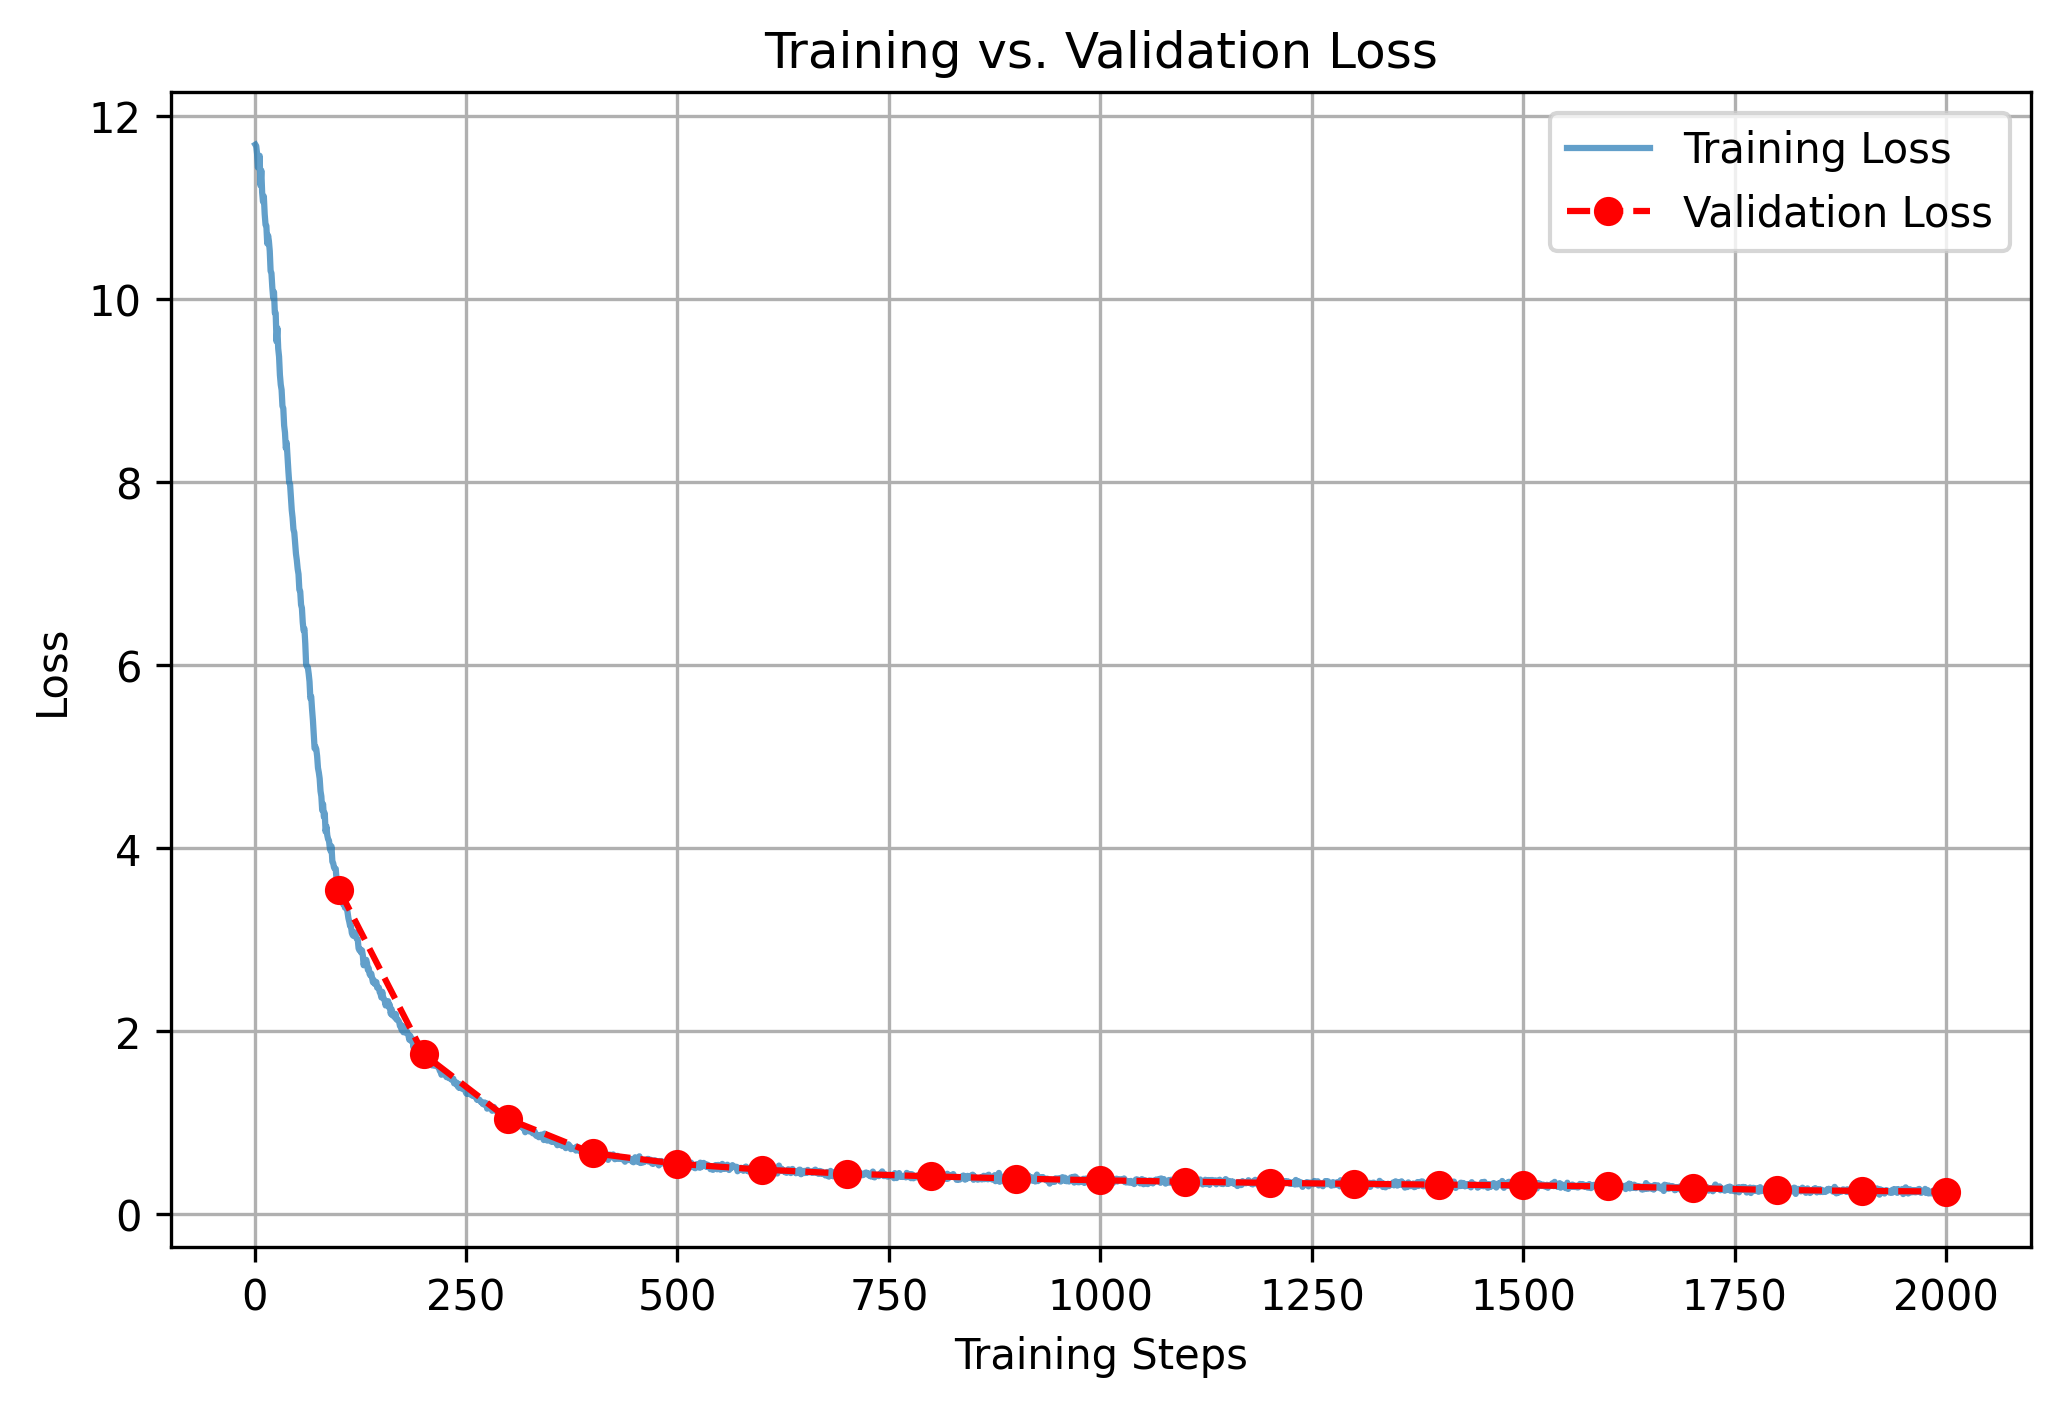

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Save Losses to CSV

train_losses = pd.Series(train_losses)
val_losses = pd.Series(val_losses)
train_losses.to_csv("csv/train_losses_modelx2.csv")
val_losses.to_csv("csv/val_losses_modelx2.csv")

# Create an array of step indices for validation losses
val_steps = list(range(eval_interval, steps + 1, eval_interval))

plt.figure(figsize=(8, 5), dpi=300)
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Training Loss", alpha=0.7)
plt.plot(val_steps, val_losses, label="Validation Loss", marker='o', linestyle="--", color="red")

plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Training vs. Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [182]:
model.load_state_dict(torch.load("models/lora_qwen2.5_final_x2.pth", map_location="cpu"))
model.eval()  # Put model in evaluation mode


Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): LoRALinear(
            (original_linear): Linear(in_features=896, out_features=896, bias=True)
          )
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): LoRALinear(
            (original_linear): Linear(in_features=896, out_features=128, bias=True)
          )
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm(

In [82]:
# Total parameters in the model
total_params = sum(p.numel() for p in model.parameters())

# Trainable parameters only
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")


Total Parameters: 494,455,040
Trainable Parameters: 422,272


In [183]:
model.eval()
val_losses = []

val_dataset = TensorDataset(val_input_ids)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

with torch.no_grad():
    for (batch,) in tqdm(val_loader, desc="Evaluating"):
        batch = batch.to(device)
        outputs = model(batch, labels=batch)
        val_losses.append(outputs.loss.item())

print(f"Average Validation Loss: {sum(val_losses) / len(val_losses)}")


Evaluating: 100%|██████████| 8/8 [00:08<00:00,  1.12s/it]

Average Validation Loss: 3.832176886498928


In [132]:
def generate_forecast(model, input_text, tokenizer, max_length=100):
    model.eval()
    input_ids = tokenizer(input_text, return_tensors="pt")["input_ids"].to(device)
    
    with torch.no_grad():
        output = model.generate(input_ids, max_new_tokens=max_length)

    return tokenizer.decode(output[0], skip_special_tokens=True)

test_prompt = "2 6 14 30"
# test_prompt = sample_data
predicted_text = generate_forecast(model, test_prompt, tokenizer)
print("Predicted Next Steps:", predicted_text)


Predicted Next Steps: 2 6 14 30 56 92 170

#### Problem:

A certain number of students are standing in a row. The teacher starts by giving each student a number from 1 to n, where n is the total number of students and 1 ≤ n ≤ 10^6. After that, the teacher gives each student a new number between 1 and n such that no two adjacent students have numbers that are consecutive integers (i.e., if one student has number x, then


In [33]:
print(model.model.layers[0].self_attn.q_proj.A.mean(), model.model.layers[0].self_attn.q_proj.A.std())


tensor(1.6243e-13, grad_fn=<MeanBackward0>) tensor(4.6808e-10, grad_fn=<StdBackward0>)


In [34]:
checkpoint = torch.load("models/lora_qwen2.5_3c_4.pth", map_location="cpu")
print(checkpoint.keys())

odict_keys(['model.embed_tokens.weight', 'model.layers.0.self_attn.q_proj.A', 'model.layers.0.self_attn.q_proj.B', 'model.layers.0.self_attn.q_proj.original_linear.weight', 'model.layers.0.self_attn.q_proj.original_linear.bias', 'model.layers.0.self_attn.k_proj.weight', 'model.layers.0.self_attn.k_proj.bias', 'model.layers.0.self_attn.v_proj.A', 'model.layers.0.self_attn.v_proj.B', 'model.layers.0.self_attn.v_proj.original_linear.weight', 'model.layers.0.self_attn.v_proj.original_linear.bias', 'model.layers.0.self_attn.o_proj.weight', 'model.layers.0.mlp.gate_proj.weight', 'model.layers.0.mlp.up_proj.weight', 'model.layers.0.mlp.down_proj.weight', 'model.layers.0.input_layernorm.weight', 'model.layers.0.post_attention_layernorm.weight', 'model.layers.1.self_attn.q_proj.A', 'model.layers.1.self_attn.q_proj.B', 'model.layers.1.self_attn.q_proj.original_linear.weight', 'model.layers.1.self_attn.q_proj.original_linear.bias', 'model.layers.1.self_attn.k_proj.weight', 'model.layers.1.self_at

In [ ]:
import re

system_id = 850  # System ID to sample

# Step 1: Load the base model
device = torch.device("cpu")
model, tokenizer = load_qwen()  # Base Qwen model

#  Step 4: Inject LoRA into q_proj and v_proj
lora_rank = 8
for layer in model.model.layers:
    layer.self_attn.q_proj = LoRALinear(layer.self_attn.q_proj, r=lora_rank)
    layer.self_attn.v_proj = LoRALinear(layer.self_attn.v_proj, r=lora_rank)

model.load_state_dict(torch.load("models/lora_qwen2.5_3c_5.pth", map_location="cpu"), strict=False)

#  Step 6: Set eval mode
model.to(device)
model.eval()

# Define parameters
time_steps = 100
forecast_horizon = 40 # Predict 1 time steps (10 values)
history_length = time_steps - forecast_horizon  # Model sees 5 time steps (10 values)

# Load and preprocess sample data
preprocessor = LLMTIMEPreprocessor()
sample_data = load_sample_data(system_id=system_id, time_steps=time_steps)  # Shape: (10,2)

# Split into training and validation sets
sample_data_train = sample_data[:history_length]  # (5,2) → 5 time steps
sample_data_val = sample_data[history_length:history_length+forecast_horizon]  # (5,2) → 5 time steps

# Preprocess (no flattening yet)
preprocessed_seq = preprocessor.preprocess_sequence(sample_data_train)  
tokenized_seq = preprocessor.tokenize_sequence(preprocessed_seq)

# Convert tokenized sequence into tensor
# input_ids = torch.tensor([tokenized_seq]).to(device)
encoded_input = tokenizer(preprocessed_seq, return_tensors="pt", padding=True, truncation=True)
input_ids = encoded_input["input_ids"].to(device)
attention_mask = encoded_input["attention_mask"].to(device)

# Generate extra tokens (to ensure enough numbers are extracted)
with torch.no_grad():
    output = model.generate(
        input_ids,
        attention_mask=attention_mask,  #  Add attention mask
        max_new_tokens= forecast_horizon * 25,
        min_length=forecast_horizon * 20,
    )

# Decode model output
decoded_output = tokenizer.decode(output[0], skip_special_tokens=True)


def extract_numerical_values(decoded_text):
    """
    Extracts numerical float values from the decoded model output using regex.
    Filters out non-numeric noise and malformed values.
    """
    matches = re.findall(r"\d*\.\d+|\d+", decoded_text)
    print(f"🧐 Extracted {len(matches)} numeric values")
    print("🔍 Extracted Matches:", matches)
    return np.array([float(x) for x in matches])


# Get only first 80 (forecast_horizon * 2) predicted values
predicted_values = extract_numerical_values(decoded_output)[:forecast_horizon * 2] * 10
predicted_values_full = extract_numerical_values(decoded_output) * 10

# Match with true values
true_values = sample_data_val.flatten()[:len(predicted_values)]
# # Extract numerical values (ensure exactly 10)
# predicted_values_full = extract_numerical_values(decoded_output) * 10

# start_index = len(sample_data_train.flatten())
# end_index = start_index + (forecast_horizon * 2)

# # Extract the correctly aligned predictions
# predicted_values = predicted_values_full[start_index:end_index]  

# # Ensure true values are correctly extracted
# true_values = sample_data_val.flatten()[:len(predicted_values)]  

print(f"🔹 True Values Length: {len(true_values)}, Predicted Values Length: {len(predicted_values)}")


print(f'lenght of decoded_output: {len(decoded_output)}')
print(f'Length tokenized sequence: {len(tokenized_seq)}')
print(f'Length true values: {len(true_values)}')  # Should be 10
print(f'Length predicted values: {len(predicted_values)}')  # Should be 10

# Evaluate predictions only if we got exactly 10 values
if len(predicted_values) == forecast_horizon * 2:
    mse = mean_squared_error(true_values, predicted_values)
    mae = mean_absolute_error(true_values, predicted_values)
    r2 = r2_score(true_values, predicted_values)
else:
    mse, mae, r2 = np.nan, np.nan, np.nan  # Model didn't generate valid predictions

# Print results
print("\n🔹 Decoded Model Output:\n", decoded_output)
print("\n🔹 True Next 5 Values:\n", true_values)
print("\n🔹 Predicted Next 5 Values:\n", predicted_values)
print(f"\n🔹 Evaluation Metrics:\nMSE: {mse:.5f} | MAE: {mae:.5f} | R² Score: {r2:.5f}")

🧐 Extracted 121 numeric values
🔍 Extracted Matches: ['0.12', '0.09', '0.13', '0.08', '0.15', '0.07', '0.18', '0.07', '0.21', '0.07', '0.25', '0.07', '0.27', '0.08', '0.29', '0.09', '0.3', '0.1', '0.3', '0.11', '0.28', '0.12', '0.25', '0.14', '0.22', '0.14', '0.19', '0.14', '0.17', '0.14', '0.15', '0.13', '0.14', '0.12', '0.14', '0.11', '0.14', '0.1', '0.15', '0.09', '0.17', '0.09', '0.18', '0.09', '0.2', '0.08', '0.22', '0.09', '0.24', '0.09', '0.25', '0.09', '0.26', '0.1', '0.25', '0.11', '0.25', '0.12', '0.23', '0.12', '0.22', '0.13', '0.2', '0.13', '0.19', '0.13', '0.17', '0.12', '0.17', '0.12', '0.16', '0.11', '0.17', '0.11', '0.17', '0.1', '0.18', '0.1', '0.19', '0.1', '0.2', '0.09', '0.21', '0.09', '0.22', '0.1', '0.23', '0.1', '0.23', '0.1', '0.23', '0.11', '0.23', '0.11', '0.22', '0.11', '0.21', '0.12', '0.2', '0.12', '0.19', '0.12', '0.19', '0.12', '0.18', '0.11', '0.18', '0.11', '0.18', '0.11', '0.18', '0.1', '0.19', '0.1', '0.19', '0.1', '0.2', '0.1', '0.2', '0.13', '1.1']
🧐

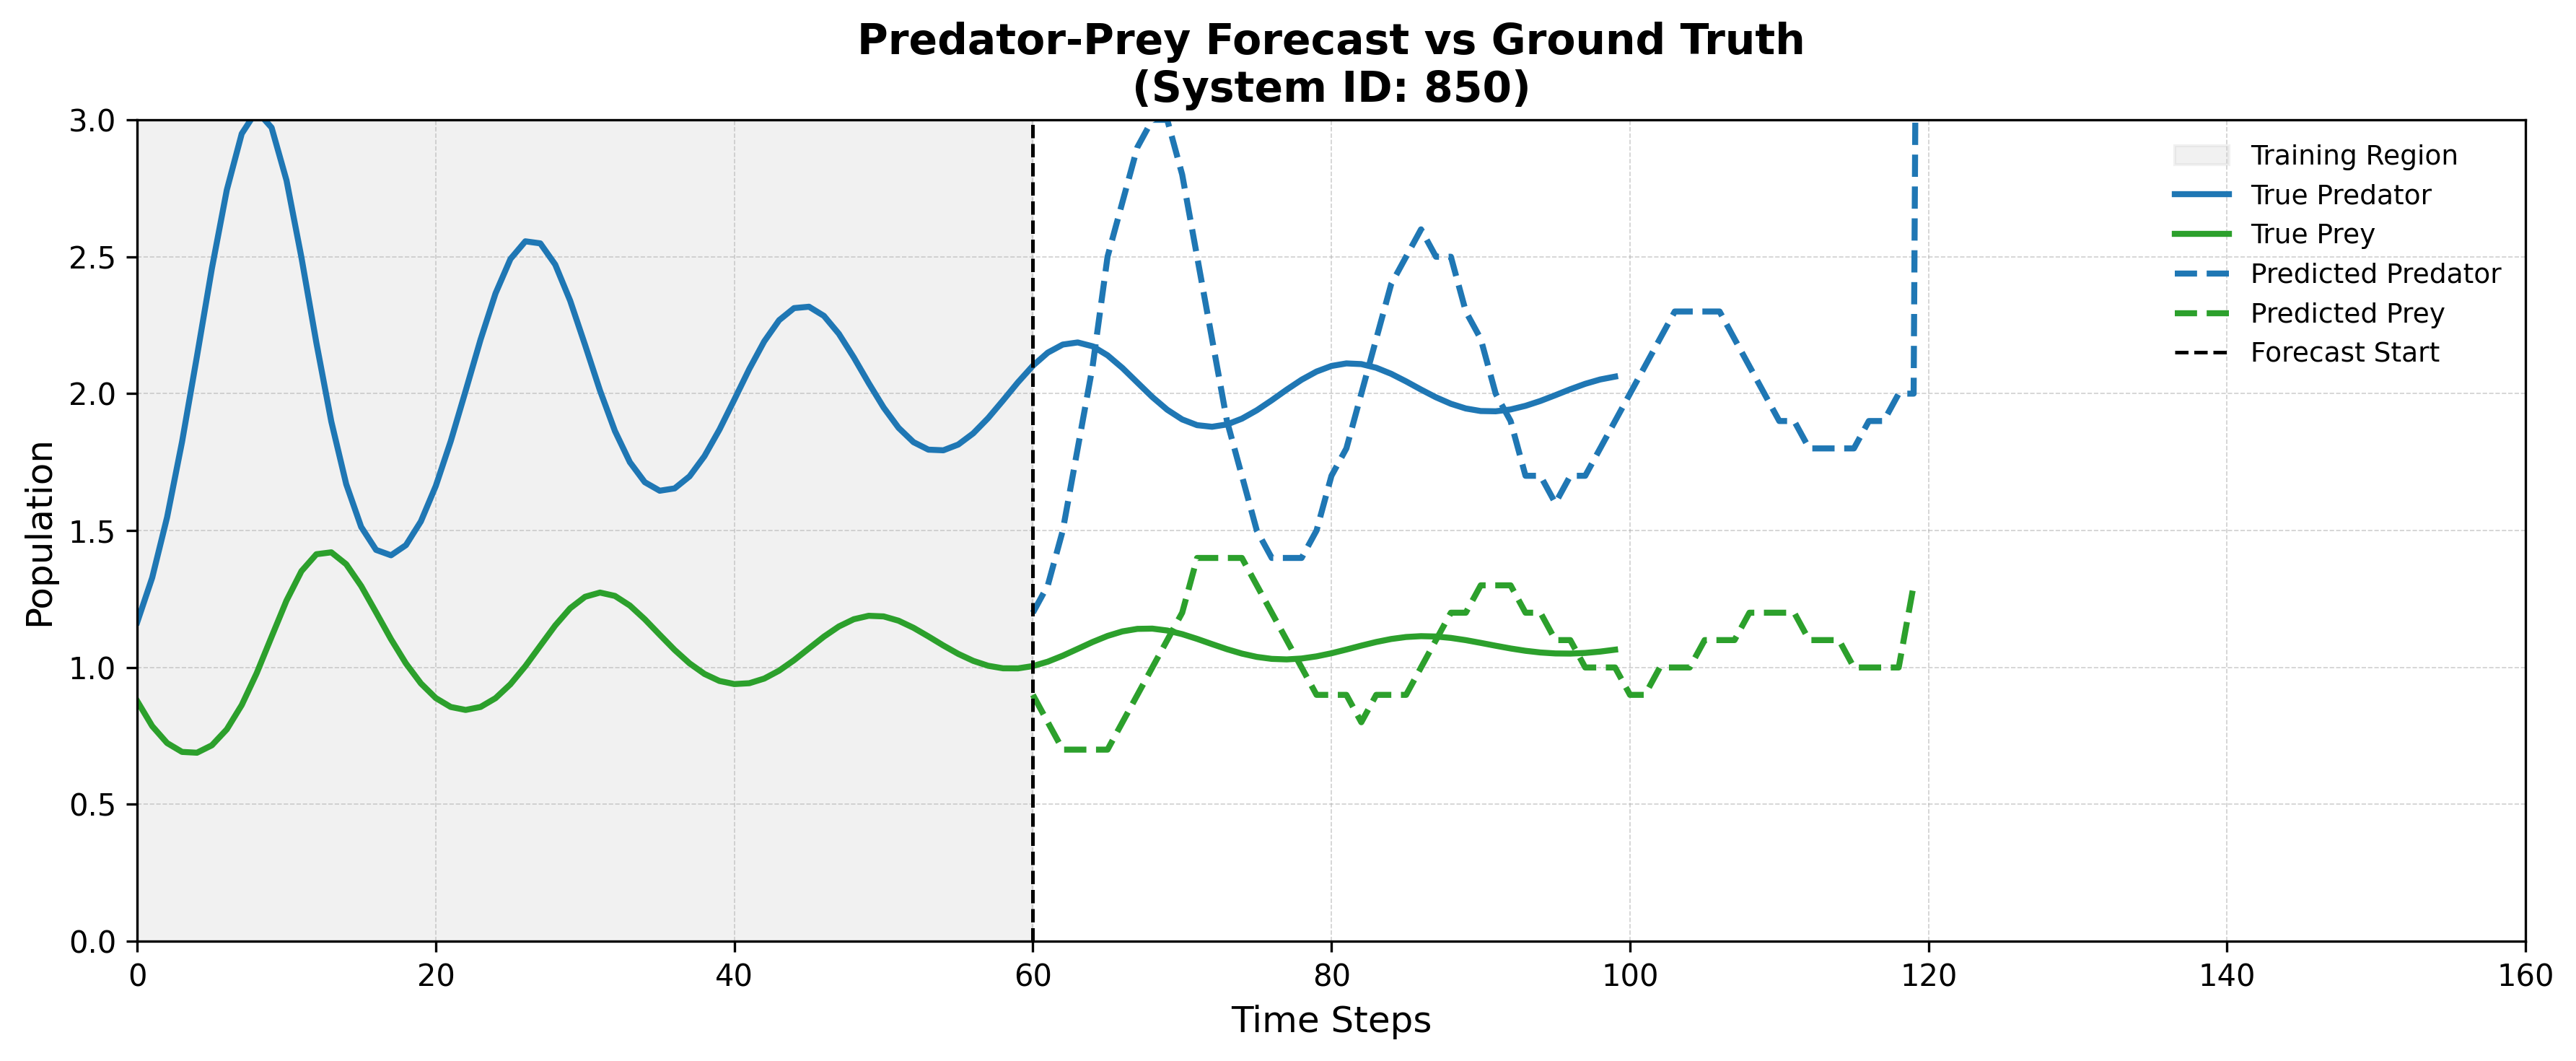

In [ ]:
# Flatten full ground truth (train + val)
full_true_values = np.append(sample_data_train.flatten(), sample_data_val.flatten())

# Make sure to consistently define even = prey, odd = predator (adjust if needed)
full_true_predator = full_true_values[::2]
full_true_prey = full_true_values[1::2]

true_predator = true_values[::2]
true_prey = true_values[1::2]

predicted_predator = predicted_values_full[::2]
predicted_prey = predicted_values_full[1::2]

# Time axes
time_true = np.arange(len(full_true_prey))
time_pred = np.arange(len(predicted_prey))

time_predicted_pred = np.arange(60, 60 + len(predicted_predator))  # or predicted_prey
time_predicted_prey = np.arange(60, 60 + len(predicted_prey))  # or predicted_prey

n_pred_to_plot = min(len(predicted_predator), 100)

predicted_predator_clipped = predicted_predator[:n_pred_to_plot]
predicted_prey_clipped = predicted_prey[:n_pred_to_plot]
time_predicted_clipped_pred = time_predicted_pred[:n_pred_to_plot]
time_predicted_clipped_prey = time_predicted_prey[:n_pred_to_plot]

plt.figure(figsize=(12, 5), dpi=300)

true_predator_color = '#1f77b4'   
pred_predator_color = '#1f77b4'  

true_prey_color = '#2ca02c'         
pred_prey_color = '#2ca02c'         

# Shade training region
plt.axvspan(0, 60, color='lightgrey', alpha=0.3, label="Training Region")

# Plot true values
plt.plot(time_true, full_true_predator, label="True Predator", linestyle='-', color=true_predator_color, linewidth=2)
plt.plot(time_true, full_true_prey, label="True Prey", linestyle='-', color=true_prey_color, linewidth=2)

# Plot predicted values
plt.plot(time_predicted_clipped_pred, predicted_predator_clipped, label="Predicted Predator", linestyle='--', color=pred_predator_color, linewidth=2)
plt.plot(time_predicted_clipped_prey, predicted_prey_clipped, label="Predicted Prey", linestyle='--', color=pred_prey_color, linewidth=2)

# Forecast start marker
plt.axvline(x=60, color='black', linestyle='--', lw=1.2, label="Forecast Start")

# Labels and layout
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Population", fontsize=12)
plt.title(f"Predator-Prey Forecast vs Ground Truth\n(System ID: {system_id})", fontsize=14, weight='bold')

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(0, 160)
plt.ylim(0, 3)
plt.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)
plt.legend(fontsize=9, loc='upper right', frameon=False)

plt.tight_layout()
plt.show()



In [53]:
time_predator_f

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
       26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
       39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50., 51.,
       52., 53., 54., 55., 56., 57., 58., 59., 60., 61., 62., 63., 64.,
       65., 66., 67., 68., 69., 70., 71., 72., 73., 74., 75., 76., 77.,
       78., 79., 80., 81.])

In [31]:
state_dict = torch.load("models/lora_qwen2.5_3c_4.pth", map_location="cpu")
for name, param in state_dict.items():
    if "A" in name or "B" in name:
        print(f"{name} → mean={param.mean():.4f}, std={param.std():.4f}")


model.layers.0.self_attn.q_proj.A → mean=0.0000, std=0.0000
model.layers.0.self_attn.q_proj.B → mean=0.0000, std=0.0000
model.layers.0.self_attn.v_proj.A → mean=0.0000, std=0.0025
model.layers.0.self_attn.v_proj.B → mean=-0.0000, std=0.0061
model.layers.1.self_attn.q_proj.A → mean=0.0000, std=0.0003
model.layers.1.self_attn.q_proj.B → mean=0.0000, std=0.0002
model.layers.1.self_attn.v_proj.A → mean=-0.0000, std=0.0018
model.layers.1.self_attn.v_proj.B → mean=0.0000, std=0.0044
model.layers.2.self_attn.q_proj.A → mean=0.0000, std=0.0000
model.layers.2.self_attn.q_proj.B → mean=0.0000, std=0.0000
model.layers.2.self_attn.v_proj.A → mean=0.0000, std=0.0019
model.layers.2.self_attn.v_proj.B → mean=0.0000, std=0.0052
model.layers.3.self_attn.q_proj.A → mean=0.0000, std=0.0022
model.layers.3.self_attn.q_proj.B → mean=-0.0000, std=0.0024
model.layers.3.self_attn.v_proj.A → mean=0.0000, std=0.0015
model.layers.3.self_attn.v_proj.B → mean=0.0000, std=0.0046
model.layers.4.self_attn.q_proj.A → m

In [ ]:
model, _ = load_qwen()

# Load LoRA weights
lora_rank = 8
for layer in model.model.layers:
    layer.self_attn.q_proj = LoRALinear(layer.self_attn.q_proj, r=lora_rank)
    layer.self_attn.v_proj = LoRALinear(layer.self_attn.v_proj, r=lora_rank)

print("LoRA q_proj A sample:", model.model.layers[0].self_attn.q_proj.A[0, 0].item())
print("LoRA q_proj B sample:", model.model.layers[0].self_attn.q_proj.B[0, 0].item())


LoRA q_proj A sample: -0.01787538081407547
LoRA q_proj B sample: 0.0


In [21]:
state_dict = torch.load("models/lora_qwen2.5_3c_4.pth", map_location="cpu")
print("Loaded keys:", list(state_dict.keys())[:5])
print("Sample A mean:", state_dict["model.model.layers.0.self_attn.q_proj.A"].mean())


Loaded keys: ['model.embed_tokens.weight', 'model.layers.0.self_attn.q_proj.A', 'model.layers.0.self_attn.q_proj.B', 'model.layers.0.self_attn.q_proj.original_linear.weight', 'model.layers.0.self_attn.q_proj.original_linear.bias']


KeyError: 'model.model.layers.0.self_attn.q_proj.A'

### Part 3b - Hyperparameter grid search

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
from accelerate import Accelerator
import pandas as pd
import itertools
import time
from coursework.qwen import load_qwen

# Force everything to CPU
device = torch.device("cpu")

# Define Hyperparameter Grid
learning_rates = [1e-5, 5e-5, 1e-4]
lora_ranks = [2, 4, 8]
num_epochs = 500  # Fixed number of optimizer steps

# Initialize Results Storage
results = []

# Start Grid Search
for lr, lora_rank in itertools.product(learning_rates, lora_ranks):
    print(f"\n🔹 Running Experiment: LR={lr}, LoRA Rank={lora_rank}")

    # Load model and move to CPU
    model, tokenizer = load_qwen()
    model.to(device)

    #  LoRA Implementation
    class LoRALinear(nn.Module):
        def __init__(self, original_linear: nn.Linear, r: int, alpha: int = None):
            super().__init__()
            assert isinstance(original_linear, nn.Linear)
            self.original_linear = original_linear
            self.original_linear.weight.requires_grad = False
            if self.original_linear.bias is not None:
                self.original_linear.bias.requires_grad = False

            in_dim = original_linear.in_features
            out_dim = original_linear.out_features
            self.r = r
            self.alpha = alpha if alpha else r

            device = original_linear.weight.device
            self.A = nn.Parameter(torch.empty(r, in_dim, device=device))
            self.B = nn.Parameter(torch.zeros(out_dim, r, device=device))  # Fixed initialization
            nn.init.kaiming_normal_(self.A, nonlinearity="linear")

        def forward(self, x):
            base_out = self.original_linear(x)
            lora_out = (x @ self.A.T) @ self.B.T
            return base_out + lora_out * (self.alpha / self.r)

    # Apply LoRA to Query & Value Projection Layers
    for layer in model.model.layers:
        layer.self_attn.q_proj = LoRALinear(layer.self_attn.q_proj, r=lora_rank)
        layer.self_attn.v_proj = LoRALinear(layer.self_attn.v_proj, r=lora_rank)

    # Load dataset
    train_texts, val_texts = load_and_preprocess("coursework/lotka_volterra_data.h5", num_systems=100, time_steps=10, fraction=0.8)

    # Tokenize dataset with sliding windows
    def process_sequences(texts, tokenizer, max_length=512, stride=256):
        all_input_ids = []
        for text in texts:
            encoding = tokenizer(text, return_tensors="pt", add_special_tokens=False)
            seq_ids = encoding.input_ids[0]

            for i in range(0, len(seq_ids), stride):
                chunk = seq_ids[i : i + max_length]
                if len(chunk) < max_length:
                    chunk = torch.cat([chunk, torch.full((max_length - len(chunk),), tokenizer.pad_token_id)])
                all_input_ids.append(chunk)
        return torch.stack(all_input_ids)

    # Convert tokenized text into tensors
    max_ctx_length = 256  # Default fixed context length for now
    train_input_ids = process_sequences(train_texts, tokenizer, max_ctx_length)
    val_input_ids = process_sequences(val_texts, tokenizer, max_ctx_length)

    # Prepare DataLoaders
    batch_size = 2
    train_dataset = TensorDataset(train_input_ids)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(val_input_ids)
    val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

    # Optimizer (only trainable LoRA parameters)
    optimizer = torch.optim.Adam((p for p in model.parameters() if p.requires_grad), lr=lr)

    # Use Accelerator for efficient training
    accelerator = Accelerator()
    model, optimizer, train_loader = accelerator.prepare(model, optimizer, train_loader)

    for param in model.parameters():
        param.data = param.data.to("cpu")
        if param.grad is not None:
            param.grad.data = param.grad.data.to("cpu")
    for buffer in model.buffers():
        buffer.data = buffer.data.to("cpu")

    train_losses = []
    val_losses = []
    eval_interval = 100  # Evaluate validation loss every 100 steps
    start_time = time.time()

    # Train LoRA Model
    model.train()
    steps = 0
    while steps < num_epochs:
        progress_bar = tqdm(train_loader, desc=f"LR={lr}, Rank={lora_rank}, Step {steps}")
        for (batch,) in progress_bar:
            optimizer.zero_grad()
            batch = batch.to(device, dtype=torch.long)

            outputs = model(batch, labels=batch)
            loss = outputs.loss
            accelerator.backward(loss)
            optimizer.step()
            steps += 1

            train_losses.append(loss.item())
            progress_bar.set_postfix(loss=loss.item())

            if steps % eval_interval == 0:
                model.eval()
                val_loss_total = 0
                with torch.no_grad():
                    for (val_batch,) in val_loader:
                        val_batch = val_batch.to(device, dtype=torch.long)
                        val_outputs = model(val_batch, labels=val_batch)
                        val_loss_total += val_outputs.loss.item()
                avg_val_loss = val_loss_total / len(val_loader)
                val_losses.append(avg_val_loss)
                print(f"Step {steps}: Validation Loss = {avg_val_loss}")
                model.train()

            if steps >= num_epochs:
                break

    # Save Results
    elapsed_time = time.time() - start_time
    result_entry = {
        "learning_rate": lr,
        "lora_rank": lora_rank,
        "final_train_loss": train_losses[-1],
        "final_val_loss": val_losses[-1] if val_losses else None,
        "time_taken_sec": elapsed_time,
    }
    results.append(result_entry)

    # Save Train & Validation Losses to CSV
    pd.DataFrame({"train_loss": train_losses}).to_csv(f"csv/train_loss_lr{lr}_rank{lora_rank}.csv", index=False)
    pd.DataFrame({"val_loss": val_losses}).to_csv(f"csv/val_loss_lr{lr}_rank{lora_rank}.csv", index=False)

    print(f"\n Finished Experiment: LR={lr}, Rank={lora_rank}")
    print(f"   Time Taken: {elapsed_time:.2f} sec")
    print(f"   Final Train Loss: {train_losses[-1]:.5f}")
    print(f"   Final Validation Loss: {val_losses[-1] if val_losses else 'N/A'}")

# Save Final Results Table
pd.DataFrame(results).to_csv("csv/grid_search_results_lr_rank.csv", index=False)
print("\nGrid Search Complete! All results saved.")


🔹 Running Experiment: LR=1e-05, LoRA Rank=2


LR=1e-05, Rank=2, Step 80:  50%|█████     | 20/40 [01:03<02:00,  6.01s/it, loss=5.71]

Step 100: Validation Loss = 5.626722908020019


LR=1e-05, Rank=2, Step 160: 100%|██████████| 40/40 [02:10<00:00,  3.26s/it, loss=2.68]


Step 200: Validation Loss = 2.6727929592132567


...

Step 300: Validation Loss = 0.17293528020381926


LR=0.0001, Rank=8, Step 360: 100%|██████████| 40/40 [01:59<00:00,  2.99s/it, loss=0.147]


Step 400: Validation Loss = 0.13137576431035997


LR=0.0001, Rank=8, Step 480:  48%|████▊     | 19/40 [01:10<01:18,  3.72s/it, loss=0.134] 

Step 500: Validation Loss = 0.1113298162817955

🔹 Finished Experiment: LR=0.0001, Rank=8
   ⏳ Time Taken: 1439.42 sec
   📉 Final Train Loss: 0.13434
   📊 Final Validation Loss: 0.1113298162817955

✅ Grid Search Complete! All results saved.


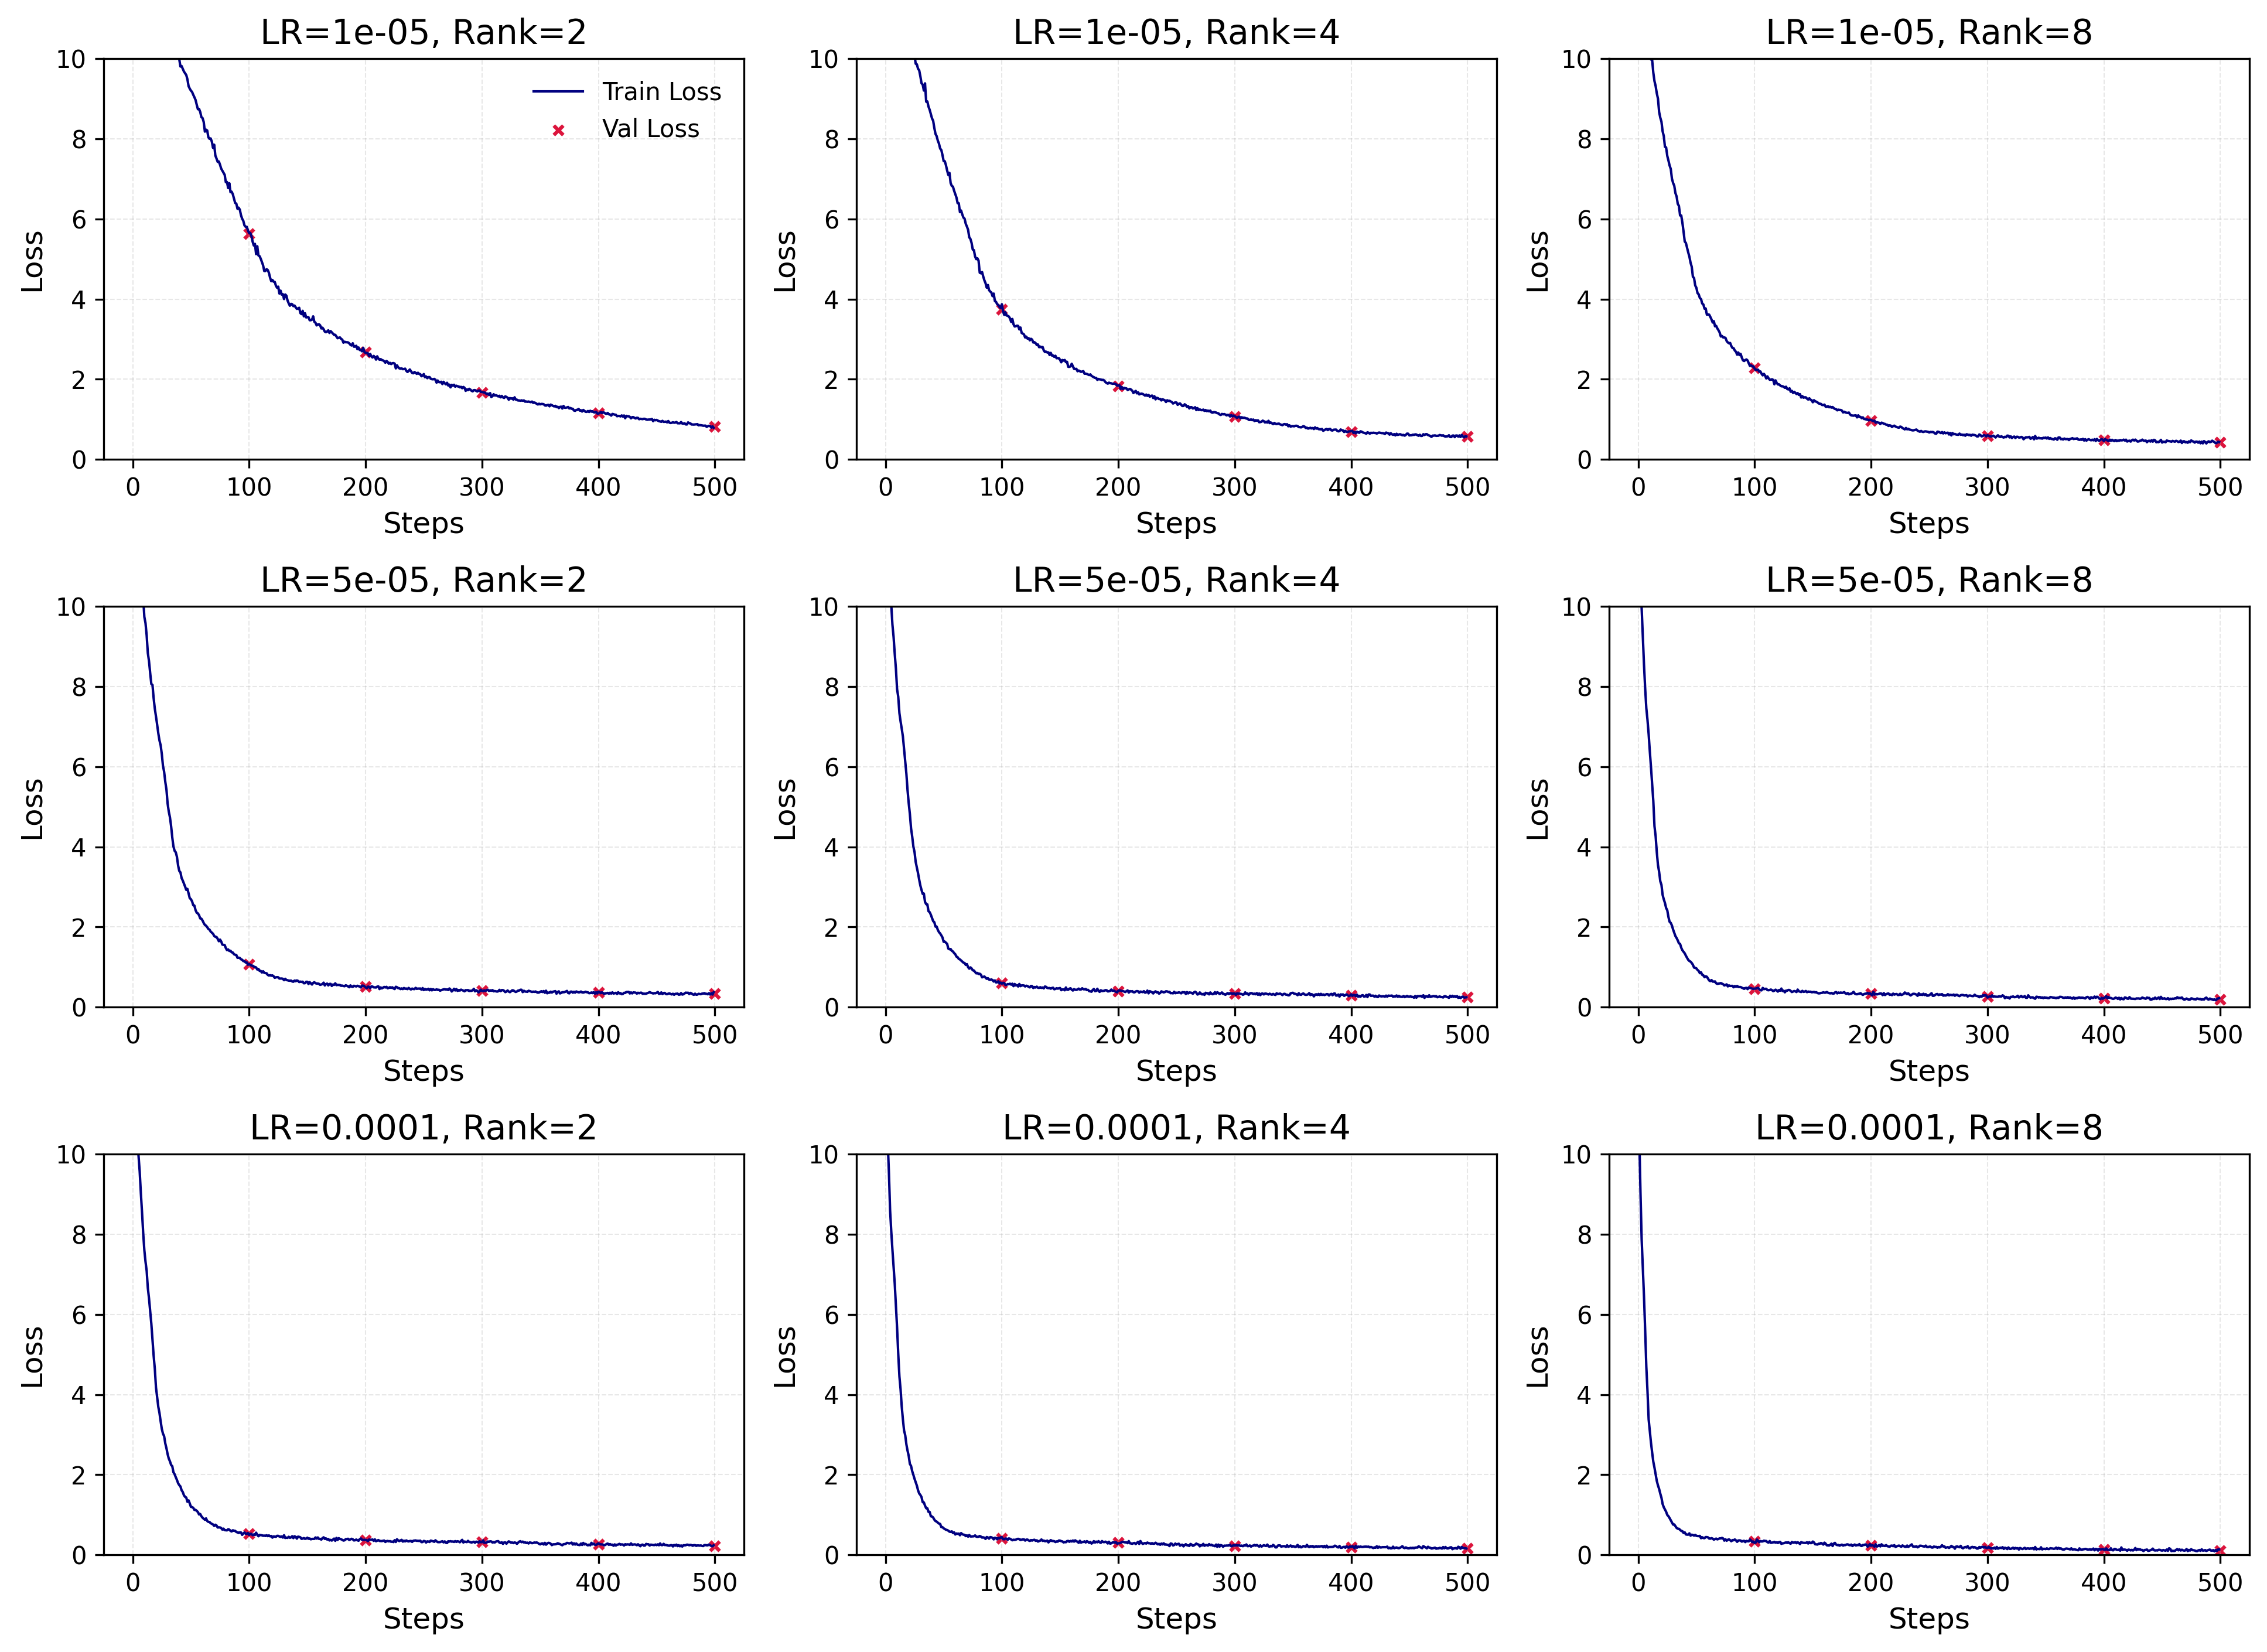

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import itertools

#  Define the grid search values
learning_rates = [1e-5, 5e-5, 1e-4]
lora_ranks = [2, 4, 8]

fig, axes = plt.subplots(len(learning_rates), len(lora_ranks), figsize=(13, 10), dpi=300)
# fig.suptitle("LoRA Grid Search: Train & Validation Loss", fontsize=16)

eval_interval = 100

for i, (lr, rank) in enumerate(itertools.product(learning_rates, lora_ranks)):
    row, col = divmod(i, len(lora_ranks))
    ax = axes[row, col]

    train_file = f"csv/train_loss_lr{lr}_rank{rank}.csv"
    val_file = f"csv/val_loss_lr{lr}_rank{rank}.csv"

    if os.path.exists(train_file) and os.path.exists(val_file):
        train_loss = pd.read_csv(train_file)["train_loss"]
        val_loss = pd.read_csv(val_file)["val_loss"]
        val_steps = list(range(eval_interval, eval_interval * len(val_loss) + 1, eval_interval))

        # Train curve
        ax.plot(train_loss, color="navy", lw=1, label="Train Loss")

        # Val points
        ax.scatter(val_steps, val_loss, color="crimson", marker="x", s=15, label="Val Loss")

        # Style
        ax.set_title(f"LR={lr}, Rank={rank}", fontsize=14)
        ax.set_ylim(0, 10)
        ax.set_xticks([0, 100, 200, 300, 400, 500])
        ax.set_xlabel("Steps", fontsize=12)
        ax.set_ylabel("Loss", fontsize=12)
        ax.tick_params(axis='both', labelsize=10)
        ax.grid(alpha=0.3, linestyle='--', linewidth=0.5)

        if row == 0 and col == 0:
            ax.legend(fontsize=10, frameon=False)
    else:
        ax.text(0.5, 0.5, "Missing Data", ha="center", va="center", fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### Validation loss vs compute efficiency graphs to find the best of the 9 models

In [ ]:
# Function to compute convergence speed
def compute_convergence_speed(train_loss_csv):
    df = pd.read_csv(train_loss_csv)
    losses = df["train_loss"].values
    window = 50  # Moving window to smooth noise
    
    # Compute moving average to reduce variance
    smoothed_loss = np.convolve(losses, np.ones(window)/window, mode='valid')

    # Find first step where loss stops decreasing significantly
    for i in range(1, len(smoothed_loss)):
        if (smoothed_loss[i-1] - smoothed_loss[i]) / smoothed_loss[i-1] < 0.0001:  # <5% loss reduction
            return i  
    
    return len(losses)  

# Load all train loss CSVs and compute convergence speed
train_loss_files = glob.glob("csv/train_loss_lr*.csv")
convergence_speeds = {f: compute_convergence_speed(f) for f in train_loss_files}


for model, conv_speed in convergence_speeds.items():
    print(f"Model {model}: Converged at step {conv_speed}")


Model csv/train_loss_lr0.0001_rank8.csv: Converged at step 101
Model csv/train_loss_lr1e-05_rank8.csv: Converged at step 292
Model csv/train_loss_lr5e-05_rank8.csv: Converged at step 153
Model csv/train_loss_lr1e-05_rank2.csv: Converged at step 500
Model csv/train_loss_lr5e-05_rank2.csv: Converged at step 256
Model csv/train_loss_lr1e-05_rank4.csv: Converged at step 439
Model csv/train_loss_lr5e-05_rank4.csv: Converged at step 176
Model csv/train_loss_lr0.0001_rank2.csv: Converged at step 147
Model csv/train_loss_lr0.0001_rank4.csv: Converged at step 132


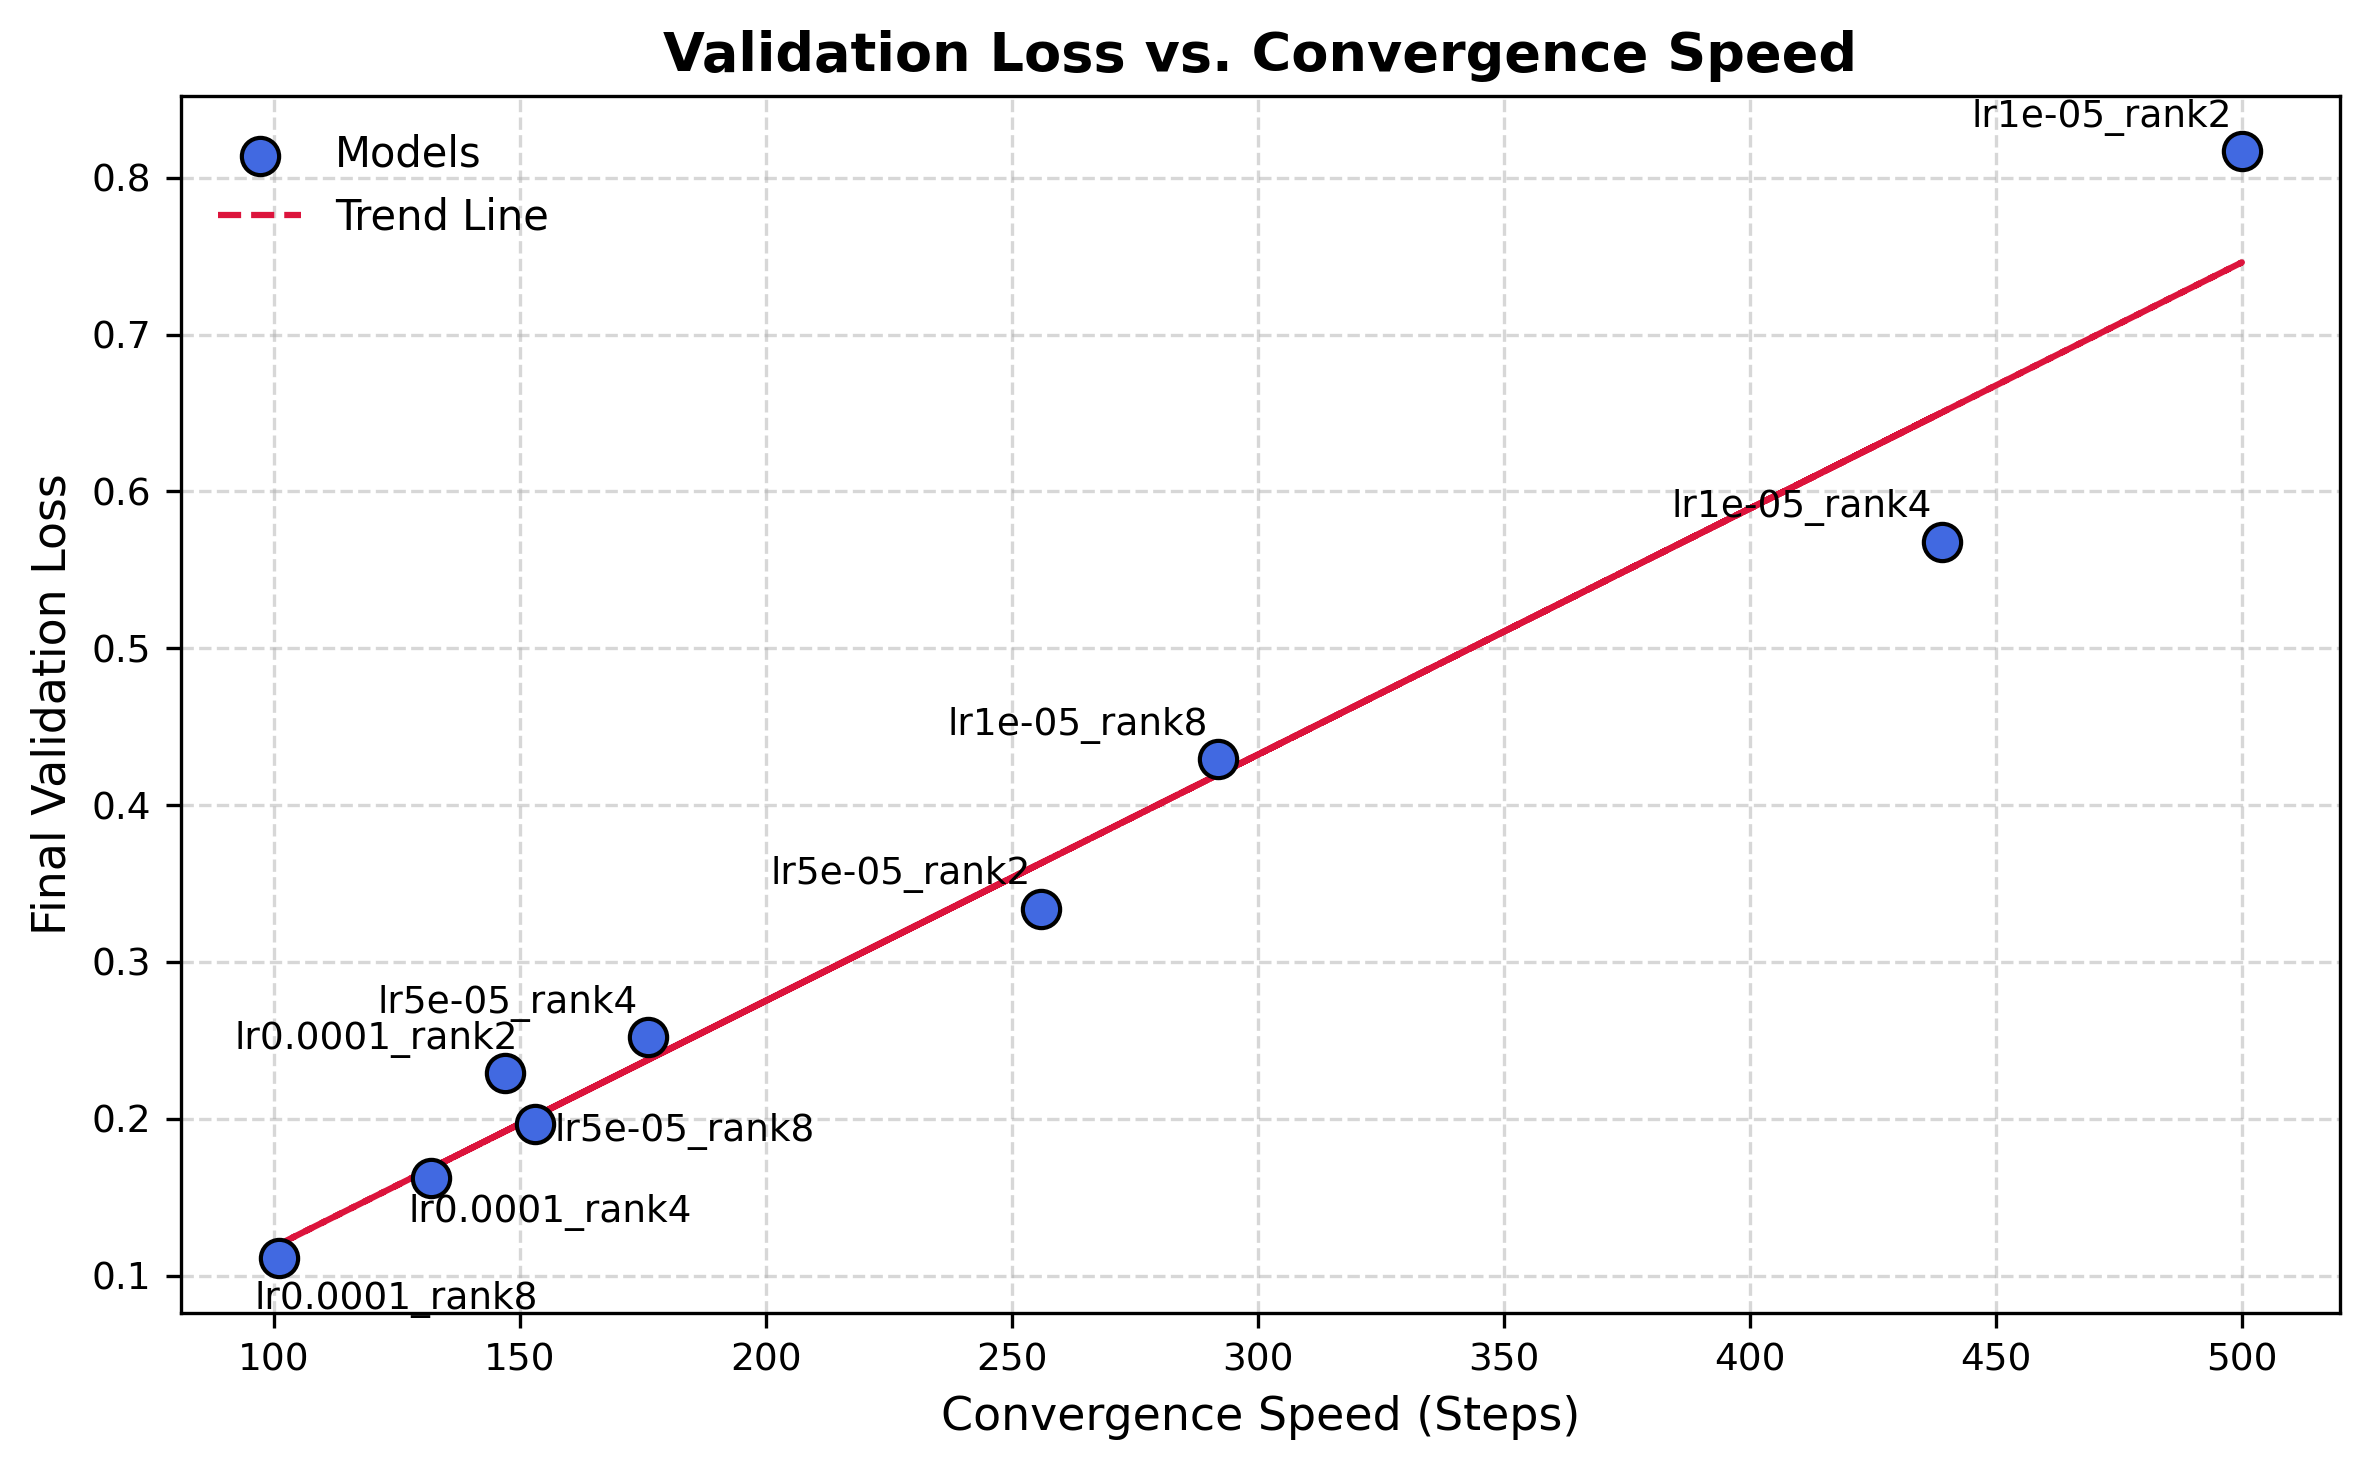

In [ ]:
import glob
import pandas as pd
import matplotlib.pyplot as plt

# Load validation losses (last entry)
val_loss_files = glob.glob("csv/val_loss_lr*.csv")
val_losses = {f: pd.read_csv(f)["val_loss"].values[-1] for f in val_loss_files}


train_loss_files = glob.glob("csv/train_loss_lr*.csv")
convergence_speeds = {f: compute_convergence_speed(f) for f in train_loss_files}


# Extract clean model names
def clean_name(f): return f.split("/")[-1].replace("train_loss_", "").replace("val_loss_", "").replace(".csv", "")

# Create aligned lists
common_models = set(map(clean_name, train_loss_files)).intersection(set(map(clean_name, val_loss_files)))

conv_speeds = [convergence_speeds[f"csv/train_loss_{m}.csv"] for m in common_models]
val_losses_plot = [val_losses[f"csv/val_loss_{m}.csv"] for m in common_models]

plt.figure(figsize=(8, 5), dpi=300)

# Plot points
plt.scatter(conv_speeds, val_losses_plot, color='royalblue', edgecolors='black',
            marker='o', s=80, label="Models", zorder=3)

# Annotate: top-left for all, bottom-right for `lr0.0001_rank4`
for i, model in enumerate(common_models):
    x, y = conv_speeds[i], val_losses_plot[i]
    
    if model == "lr0.0001_rank4":
        ha, va = "right", "top"
        offset_x, offset_y = 53, -0.01
    elif model == "lr0.0001_rank8":
        ha, va = "left", "top"
        offset_x, offset_y = -5, -0.015
    elif model == "lr5e-05_rank8":
        ha, va = "right", "bottom"
        offset_x, offset_y = 57, -0.016
    else:
        ha, va = "left", "bottom"
        offset_x, offset_y = -55, 0.01
    
    plt.annotate(model, (x + offset_x, y + offset_y),
                 fontsize=9, ha=ha, va=va, color='black')

# Trend line
z = np.polyfit(conv_speeds, val_losses_plot, 1)
p = np.poly1d(z)
plt.plot(conv_speeds, p(conv_speeds), linestyle="--", color="crimson", linewidth=1.5, label="Trend Line", zorder=2)

# Axis, grid, legend
plt.xlabel("Convergence Speed (Steps)", fontsize=11)
plt.ylabel("Final Validation Loss", fontsize=11)
plt.title("Validation Loss vs. Convergence Speed", fontsize=13, fontweight="semibold")
plt.grid(True, linestyle="--", alpha=0.5, zorder=0)
plt.legend(frameon=False, fontsize=10)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Extract model names, FLOPS, and validation loss
model_names = list(flops_per_model.keys())
flops_values = list(flops_per_model.values())

# Assuming you have val_loss_data dictionary from previous steps
val_losses_plot = [val_losses[f"csv/val_loss_{m}.csv"] for m in common_models]


# Scatter plot
plt.figure(figsize=(8, 5), dpi=200)
plt.scatter(flops_values, val_losses, color='b', marker='o', s=100, edgecolors='black', alpha=0.8)

# Add model labels
for i, model in enumerate(model_names):
    plt.annotate(model, (flops_values[i], val_losses[i]), fontsize=9, ha='right', va='bottom', color='black')

# Labels
plt.xlabel("Total FLOPS (log scale)", fontsize=12)
plt.ylabel("Final Validation Loss", fontsize=12)
plt.title("Validation Loss vs. Compute Cost", fontsize=14, fontweight="bold")
plt.xscale("log")  # Log-scale for better readability
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


KeyError: 'Seq=128, Layers=12'

### Part 3c - Training best model (0.0001, 8)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
from accelerate import Accelerator
from coursework.qwen import load_qwen

#  Force everything to CPU
device = torch.device("cpu")

# Load model and move to CPU
model, tokenizer = load_qwen()
model.to(device)

# LoRA Implementation
class LoRALinear(nn.Module):
    def __init__(self, original_linear: nn.Linear, r: int, alpha: int = None):
        super().__init__()
        assert isinstance(original_linear, nn.Linear)
        self.original_linear = original_linear
        self.original_linear.weight.requires_grad = False
        if self.original_linear.bias is not None:
            self.original_linear.bias.requires_grad = False

        in_dim = original_linear.in_features
        out_dim = original_linear.out_features
        self.r = r
        self.alpha = alpha if alpha else r

        device = original_linear.weight.device
        self.A = nn.Parameter(torch.empty(r, in_dim, device=device))
        self.B = nn.Parameter(torch.zeros(out_dim, r, device=device))  #  Fixed initialization

        # Use He initialization for A
        nn.init.kaiming_normal_(self.A, nonlinearity="linear")

    def forward(self, x):
        base_out = self.original_linear(x)
        lora_out = (x @ self.A.T) @ self.B.T
        return base_out + lora_out * (self.alpha / self.r)

# Apply LoRA to Query & Value Projection Layers
lora_rank = 8
for layer in model.model.layers:
    layer.self_attn.q_proj = LoRALinear(layer.self_attn.q_proj, r=lora_rank)  # Do not move to device here
    layer.self_attn.v_proj = LoRALinear(layer.self_attn.v_proj, r=lora_rank)

# Load dataset
train_texts, val_texts = load_and_preprocess("coursework/lotka_volterra_data.h5", num_systems=100, time_steps=10, fraction=0.8) 

# Tokenize dataset with sliding windows
def process_sequences(texts, tokenizer, max_length=512, stride=256):  # Fixed max_length & stride
    all_input_ids = []
    for text in texts:
        encoding = tokenizer(text, return_tensors="pt", add_special_tokens=False)
        seq_ids = encoding.input_ids[0]  # Ensure correct dtype

        for i in range(0, len(seq_ids), stride):
            chunk = seq_ids[i : i + max_length]
            if len(chunk) < max_length:
                chunk = torch.cat([chunk, torch.full((max_length - len(chunk),), tokenizer.pad_token_id)])
            all_input_ids.append(chunk)
    
    return torch.stack(all_input_ids)

# Set optimized training settings
max_ctx_length = 256 
batch_size = 2  
learning_rate = 0.0001

# Convert tokenized text into tensors
train_input_ids = process_sequences(train_texts, tokenizer, max_ctx_length)
val_input_ids = process_sequences(val_texts, tokenizer, max_ctx_length)

#  Prepare DataLoaders
train_dataset = TensorDataset(train_input_ids)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(val_input_ids)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

# Optimizer (only trainable LoRA parameters)
optimizer = torch.optim.Adam((p for p in model.parameters() if p.requires_grad), lr=learning_rate, weight_decay=0.05)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15000)

# Use Accelerator for efficient training
accelerator = Accelerator()
model, optimizer, train_loader = accelerator.prepare(model, optimizer, train_loader)

train_losses = []
val_losses = []
true_series = []
predicted_series = []
eval_interval = 1000  # Evaluate validation loss every 100 steps

for param in model.parameters():
    param.data = param.data.to("cpu")
    if param.grad is not None:
        param.grad.data = param.grad.data.to("cpu")

for buffer in model.buffers():
    buffer.data = buffer.data.to("cpu")

# Train LoRA Model
model.train()
steps = 0
while steps < 15000:
    progress_bar = tqdm(train_loader, desc=f"Steps {steps}")
    for (batch,) in progress_bar:
        optimizer.zero_grad()
        batch = batch.to(device, dtype=torch.long)  

        outputs = model(batch, labels=batch)
        loss = outputs.loss
        accelerator.backward(loss)
        optimizer.step()
        steps += 1

        train_losses.append(loss.item())

        progress_bar.set_postfix(loss=loss.item())

        if steps % eval_interval == 0:
            model.eval()
            val_loss_total = 0
            with torch.no_grad():
                for (val_batch,) in val_loader:
                    val_batch = val_batch.to(device, dtype=torch.long)
                    val_outputs = model(val_batch, labels=val_batch)
                    val_loss_total += val_outputs.loss.item()
            avg_val_loss = val_loss_total / len(val_loader)
            val_losses.append(avg_val_loss)
            print(f"Step {steps}: Validation Loss = {avg_val_loss}")
            model.train()  # Switch back to training model

        if steps >= 15000:
            break

# Final Model Save
torch.save(model.state_dict(), "models/lora_qwen2.5_3c_5.pth")

# Save Train & Validation Losses to CSV
pd.DataFrame({"train_loss": train_losses}).to_csv(f"csv/train_loss_3c_5.csv", index=False)
pd.DataFrame({"val_loss": val_losses}).to_csv(f"csv/val_loss_3c_5.csv", index=False)

Steps 960: 100%|██████████| 40/40 [01:48<00:00,  2.70s/it, loss=0.115]


Step 1000: Validation Loss = 0.13847797363996506


Steps 1960: 100%|██████████| 40/40 [01:45<00:00,  2.65s/it, loss=0.104] 


Step 2000: Validation Loss = 0.10774580389261246


Steps 2960: 100%|██████████| 40/40 [01:49<00:00,  2.75s/it, loss=0.0872]


...

Steps 13960: 100%|██████████| 40/40 [01:47<00:00,  2.68s/it, loss=0.0246]


Step 14000: Validation Loss = 0.21413527727127074


Steps 14960:  98%|█████████▊| 39/40 [01:49<00:02,  2.81s/it, loss=0.0328]

Step 15000: Validation Loss = 0.20985472202301025


NameError: name 'pd' is not defined

In [ ]:
import pandas as pd

# Final Model Save
torch.save(model.state_dict(), "models/lora_qwen2.5_3c_5.pth")

# Save Train & Validation Losses to CSV
pd.DataFrame({"train_loss": train_losses}).to_csv(f"csv/train_loss_3c_5.csv", index=False)
pd.DataFrame({"val_loss": val_losses}).to_csv(f"csv/val_loss_3c_5.csv", index=False)

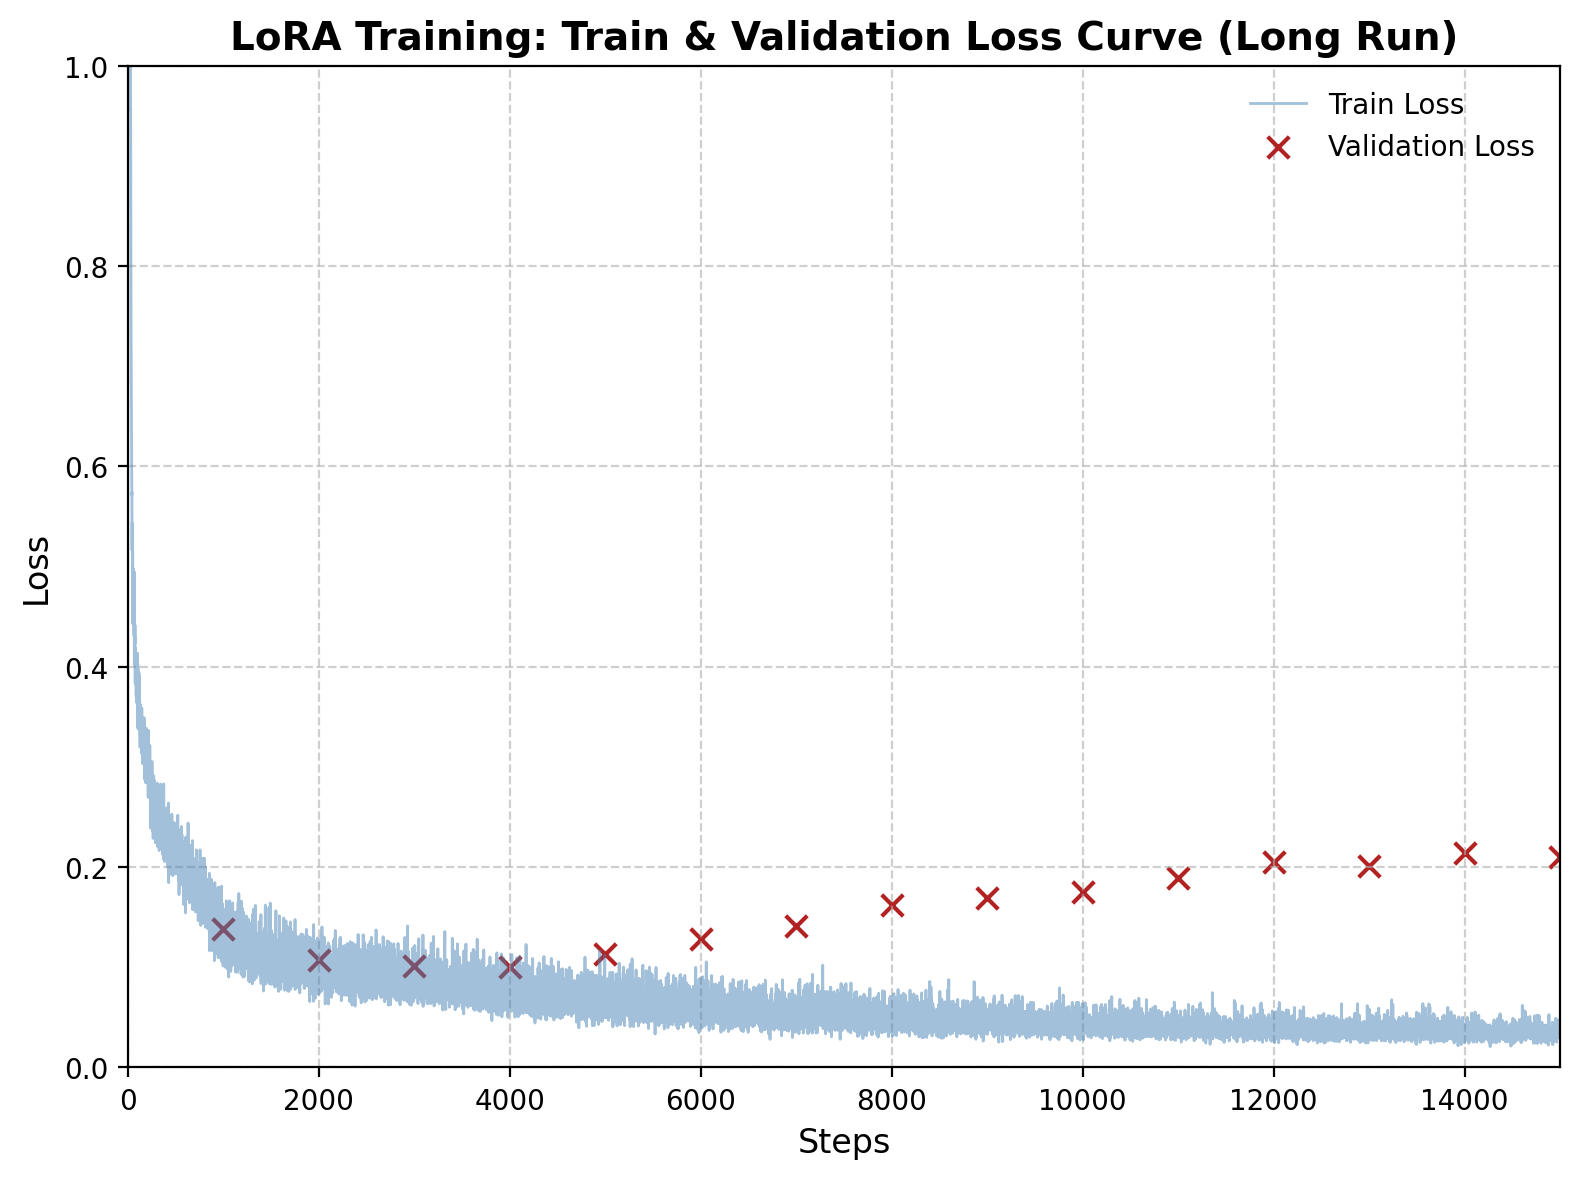

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load training and validation loss data
train_loss = pd.read_csv("csv/train_loss_3c_5.csv")["train_loss"]
val_loss = pd.read_csv("csv/val_loss_3c_5.csv")["val_loss"]

# Generate x-axis values
train_steps = range(len(train_loss))
val_steps = [i * 1000 for i in range(1, len(val_loss)+1)]  # Validation loss is recorded every 100 steps


plt.figure(figsize=(8, 6), dpi=200)

# Plot training loss with smoother style
plt.plot(train_steps, train_loss, label="Train Loss", color="steelblue", linewidth=1, alpha=0.5)

# Overlay validation loss clearly
plt.scatter(val_steps, val_loss, color="firebrick", label="Validation Loss", marker="x", s=60, linewidths=1.5)

# Aesthetics
plt.ylim(0, 1)
plt.xlim(0, max(train_steps))
plt.xlabel("Steps", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("LoRA Training: Train & Validation Loss Curve (Long Run)", fontsize=14, fontweight="bold")

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()



### Part 3b II: Context length

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
from accelerate import Accelerator
from coursework.qwen import load_qwen

# Force everything to CPU
device = torch.device("cpu")

# Context Lengths to Test
context_lengths = [128, 512, 768]

# Iterate Over Context Lengths
for max_ctx_length in context_lengths:
    print(f"\n🔹 Running Experiment with Context Length: {max_ctx_length}")

    # Load model and move to CPU
    model, tokenizer = load_qwen()
    model.to(device)

    # LoRA Implementation
    class LoRALinear(nn.Module):
        def __init__(self, original_linear: nn.Linear, r: int, alpha: int = None):
            super().__init__()
            assert isinstance(original_linear, nn.Linear)
            self.original_linear = original_linear
            self.original_linear.weight.requires_grad = False
            if self.original_linear.bias is not None:
                self.original_linear.bias.requires_grad = False

            in_dim = original_linear.in_features
            out_dim = original_linear.out_features
            self.r = r
            self.alpha = alpha if alpha else r

            device = original_linear.weight.device
            self.A = nn.Parameter(torch.empty(r, in_dim, device=device))
            self.B = nn.Parameter(torch.zeros(out_dim, r, device=device)) 
            nn.init.kaiming_normal_(self.A, nonlinearity="linear")

        def forward(self, x):
            base_out = self.original_linear(x)
            lora_out = (x @ self.A.T) @ self.B.T
            return base_out + lora_out * (self.alpha / self.r)

    # Apply LoRA to Query & Value Projection Layers
    lora_rank = 8
    for layer in model.model.layers:
        layer.self_attn.q_proj = LoRALinear(layer.self_attn.q_proj, r=lora_rank)
        layer.self_attn.v_proj = LoRALinear(layer.self_attn.v_proj, r=lora_rank)

    # Load dataset
    train_texts, val_texts = load_and_preprocess("coursework/lotka_volterra_data.h5", num_systems=100, time_steps=10, fraction=0.8)

    # Tokenize dataset with sliding windows
    def process_sequences(texts, tokenizer, max_length=512, stride=256):
        all_input_ids = []
        for text in texts:
            encoding = tokenizer(text, return_tensors="pt", add_special_tokens=False)
            seq_ids = encoding.input_ids[0]

            for i in range(0, len(seq_ids), stride):
                chunk = seq_ids[i : i + max_length]
                if len(chunk) < max_length:
                    chunk = torch.cat([chunk, torch.full((max_length - len(chunk),), tokenizer.pad_token_id)])
                all_input_ids.append(chunk)
        return torch.stack(all_input_ids)

    # Convert tokenized text into tensors
    train_input_ids = process_sequences(train_texts, tokenizer, max_ctx_length)
    val_input_ids = process_sequences(val_texts, tokenizer, max_ctx_length)

    # Prepare DataLoaders
    batch_size = 2
    train_dataset = TensorDataset(train_input_ids)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(val_input_ids)
    val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

    # Optimizer & Scheduler
    learning_rate = 0.0001
    optimizer = torch.optim.Adam((p for p in model.parameters() if p.requires_grad), lr=learning_rate, weight_decay=0.02)
    # scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=4000, gamma=0.5)

    # Use Accelerator for efficient training
    accelerator = Accelerator()
    model, optimizer, train_loader = accelerator.prepare(model, optimizer, train_loader)

    train_losses = []
    val_losses = []
    eval_interval = 500  # Evaluate every 1000 steps

    for param in model.parameters():
        param.data = param.data.to("cpu")
        if param.grad is not None:
            param.grad.data = param.grad.data.to("cpu")

    for buffer in model.buffers():
        buffer.data = buffer.data.to("cpu")

    # Train LoRA Model
    model.train()
    steps = 0
    while steps < 400:
        progress_bar = tqdm(train_loader, desc=f"Context {max_ctx_length} | Steps {steps}")
        for (batch,) in progress_bar:
            optimizer.zero_grad()
            batch = batch.to(device, dtype=torch.long)

            outputs = model(batch, labels=batch)
            loss = outputs.loss
            accelerator.backward(loss)
            optimizer.step()
            scheduler.step()
            steps += 1

            train_losses.append(loss.item())
            progress_bar.set_postfix(loss=loss.item())

            # Evaluate validation loss
            if steps % eval_interval == 0:
                model.eval()
                val_loss_total = 0
                with torch.no_grad():
                    for (val_batch,) in val_loader:
                        val_batch = val_batch.to(device, dtype=torch.long)
                        val_outputs = model(val_batch, labels=val_batch)
                        val_loss_total += val_outputs.loss.item()
                avg_val_loss = val_loss_total / len(val_loader)
                val_losses.append(avg_val_loss)
                print(f"Step {steps}: Validation Loss = {avg_val_loss}")
                model.train()

            if steps >= 400:
                break

    # Save Model Checkpoint
    torch.save(model.state_dict(), f"models/lora_qwen2.5_ctx{max_ctx_length}_testing.pth")

    # Save Train & Validation Losses to CSV
    pd.DataFrame({"train_loss": train_losses}).to_csv(f"csv/train_loss_ctx{max_ctx_length}.csv", index=False)
    pd.DataFrame({"val_loss": val_losses}).to_csv(f"csv/val_loss_ctx{max_ctx_length}.csv", index=False)

    print(f"\nFinished Experiment with Context Length {max_ctx_length}\n")



🔹 Running Experiment with Context Length: 128


Context 128 | Steps 0: 100%|██████████| 40/40 [01:13<00:00,  1.85s/it, loss=0.645]
Context 128 | Steps 40: 100%|██████████| 40/40 [00:56<00:00,  1.42s/it, loss=0.489]
Context 128 | Steps 80: 100%|██████████| 40/40 [00:49<00:00,  1.23s/it, loss=0.476]
Context 128 | Steps 120: 100%|██████████| 40/40 [00:49<00:00,  1.24s/it, loss=0.378]
Context 128 | Steps 160: 100%|██████████| 40/40 [00:52<00:00,  1.32s/it, loss=0.291]
Context 128 | Steps 200: 100%|██████████| 40/40 [00:50<00:00,  1.27s/it, loss=0.301]
Context 128 | Steps 240: 100%|██████████| 40/40 [00:55<00:00,  1.40s/it, loss=0.21] 
Context 128 | Steps 280: 100%|██████████| 40/40 [00:52<00:00,  1.30s/it, loss=0.258]
Context 128 | Steps 320: 100%|██████████| 40/40 [00:54<00:00,  1.35s/it, loss=0.202]
Context 128 | Steps 360:  98%|█████████▊| 39/40 [00:50<00:01,  1.28s/it, loss=0.188]



✅ Finished Experiment with Context Length 128


🔹 Running Experiment with Context Length: 512


Context 512 | Steps 0: 100%|██████████| 40/40 [07:11<00:00, 10.80s/it, loss=0.598]
Context 512 | Steps 40: 100%|██████████| 40/40 [07:24<00:00, 11.12s/it, loss=0.279]
Context 512 | Steps 80: 100%|██████████| 40/40 [07:25<00:00, 11.13s/it, loss=0.222]
Context 512 | Steps 120: 100%|██████████| 40/40 [07:13<00:00, 10.83s/it, loss=0.189]
Context 512 | Steps 160: 100%|██████████| 40/40 [07:08<00:00, 10.71s/it, loss=0.175]
Context 512 | Steps 200: 100%|██████████| 40/40 [07:21<00:00, 11.04s/it, loss=0.176]
Context 512 | Steps 240: 100%|██████████| 40/40 [06:22<00:00,  9.57s/it, loss=0.15] 
Context 512 | Steps 280: 100%|██████████| 40/40 [06:17<00:00,  9.44s/it, loss=0.159]
Context 512 | Steps 320: 100%|██████████| 40/40 [06:14<00:00,  9.36s/it, loss=0.145]
Context 512 | Steps 360:  98%|█████████▊| 39/40 [06:14<00:09,  9.59s/it, loss=0.155]



✅ Finished Experiment with Context Length 512


🔹 Running Experiment with Context Length: 768


Context 768 | Steps 0: 100%|██████████| 40/40 [13:38<00:00, 20.45s/it, loss=0.522]
Context 768 | Steps 40: 100%|██████████| 40/40 [13:26<00:00, 20.17s/it, loss=0.22] 
Context 768 | Steps 80: 100%|██████████| 40/40 [16:42<00:00, 25.06s/it, loss=0.172]
Context 768 | Steps 120: 100%|██████████| 40/40 [16:06<00:00, 24.17s/it, loss=0.139]
Context 768 | Steps 160: 100%|██████████| 40/40 [15:12<00:00, 22.82s/it, loss=0.132]
Context 768 | Steps 200: 100%|██████████| 40/40 [14:06<00:00, 21.16s/it, loss=0.132]
Context 768 | Steps 240: 100%|██████████| 40/40 [14:42<00:00, 22.06s/it, loss=0.117]
Context 768 | Steps 280: 100%|██████████| 40/40 [15:04<00:00, 22.61s/it, loss=0.122]
Context 768 | Steps 320: 100%|██████████| 40/40 [13:48<00:00, 20.72s/it, loss=0.113] 
Context 768 | Steps 360:  98%|█████████▊| 39/40 [22:57<00:35, 35.31s/it, loss=0.113] 



✅ Finished Experiment with Context Length 768



In [ ]:
# Load validation data once
_, val_texts = load_and_preprocess("coursework/lotka_volterra_data.h5", num_systems=100, time_steps=10, fraction=0.8)

# Loop over context lengths
context_lengths = [128, 512, 768]
device = torch.device("cpu")
results = []

for ctx in context_lengths:
    print(f"\n🔍 Evaluating Model with Context Length: {ctx}")
    
    # Load model & tokenizer
    model, tokenizer = load_qwen()
    model.to(device)

    # Apply LoRA
    lora_rank = 8
    for layer in model.model.layers:
        layer.self_attn.q_proj = LoRALinear(layer.self_attn.q_proj, r=lora_rank)
        layer.self_attn.v_proj = LoRALinear(layer.self_attn.v_proj, r=lora_rank)

    # Load LoRA weights
    model_path = f"models/lora_qwen2.5_ctx{ctx}_testing.pth"
    model.load_state_dict(torch.load(model_path, map_location=device))

    # Prepare val_loader for this context
    val_input_ids = process_sequences(val_texts, tokenizer, max_length=ctx)
    val_dataset = TensorDataset(val_input_ids)
    val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

    # Compute validation loss
    model.eval()
    val_loss_total = 0
    with torch.no_grad():
        for (val_batch,) in val_loader:
            val_batch = val_batch.to(device, dtype=torch.long)
            val_outputs = model(val_batch, labels=val_batch)
            val_loss_total += val_outputs.loss.item()
    avg_val_loss = val_loss_total / len(val_loader)
    
    results.append((ctx, avg_val_loss))
    print(f"Context Length {ctx}: Final Validation Loss = {avg_val_loss:.4f}")

# Optional: Print summary
print("\n Final Validation Losses:")
for ctx, loss in results:
    print(f"Context Length {ctx}: {loss:.4f}")


🔍 Evaluating Model with Context Length: 128
✅ Context Length 128: Final Validation Loss = 0.2063

🔍 Evaluating Model with Context Length: 512
✅ Context Length 512: Final Validation Loss = 0.1503

🔍 Evaluating Model with Context Length: 768
✅ Context Length 768: Final Validation Loss = 0.1083

📊 Final Validation Losses:
Context Length 128: 0.2063
Context Length 512: 0.1503
Context Length 768: 0.1083


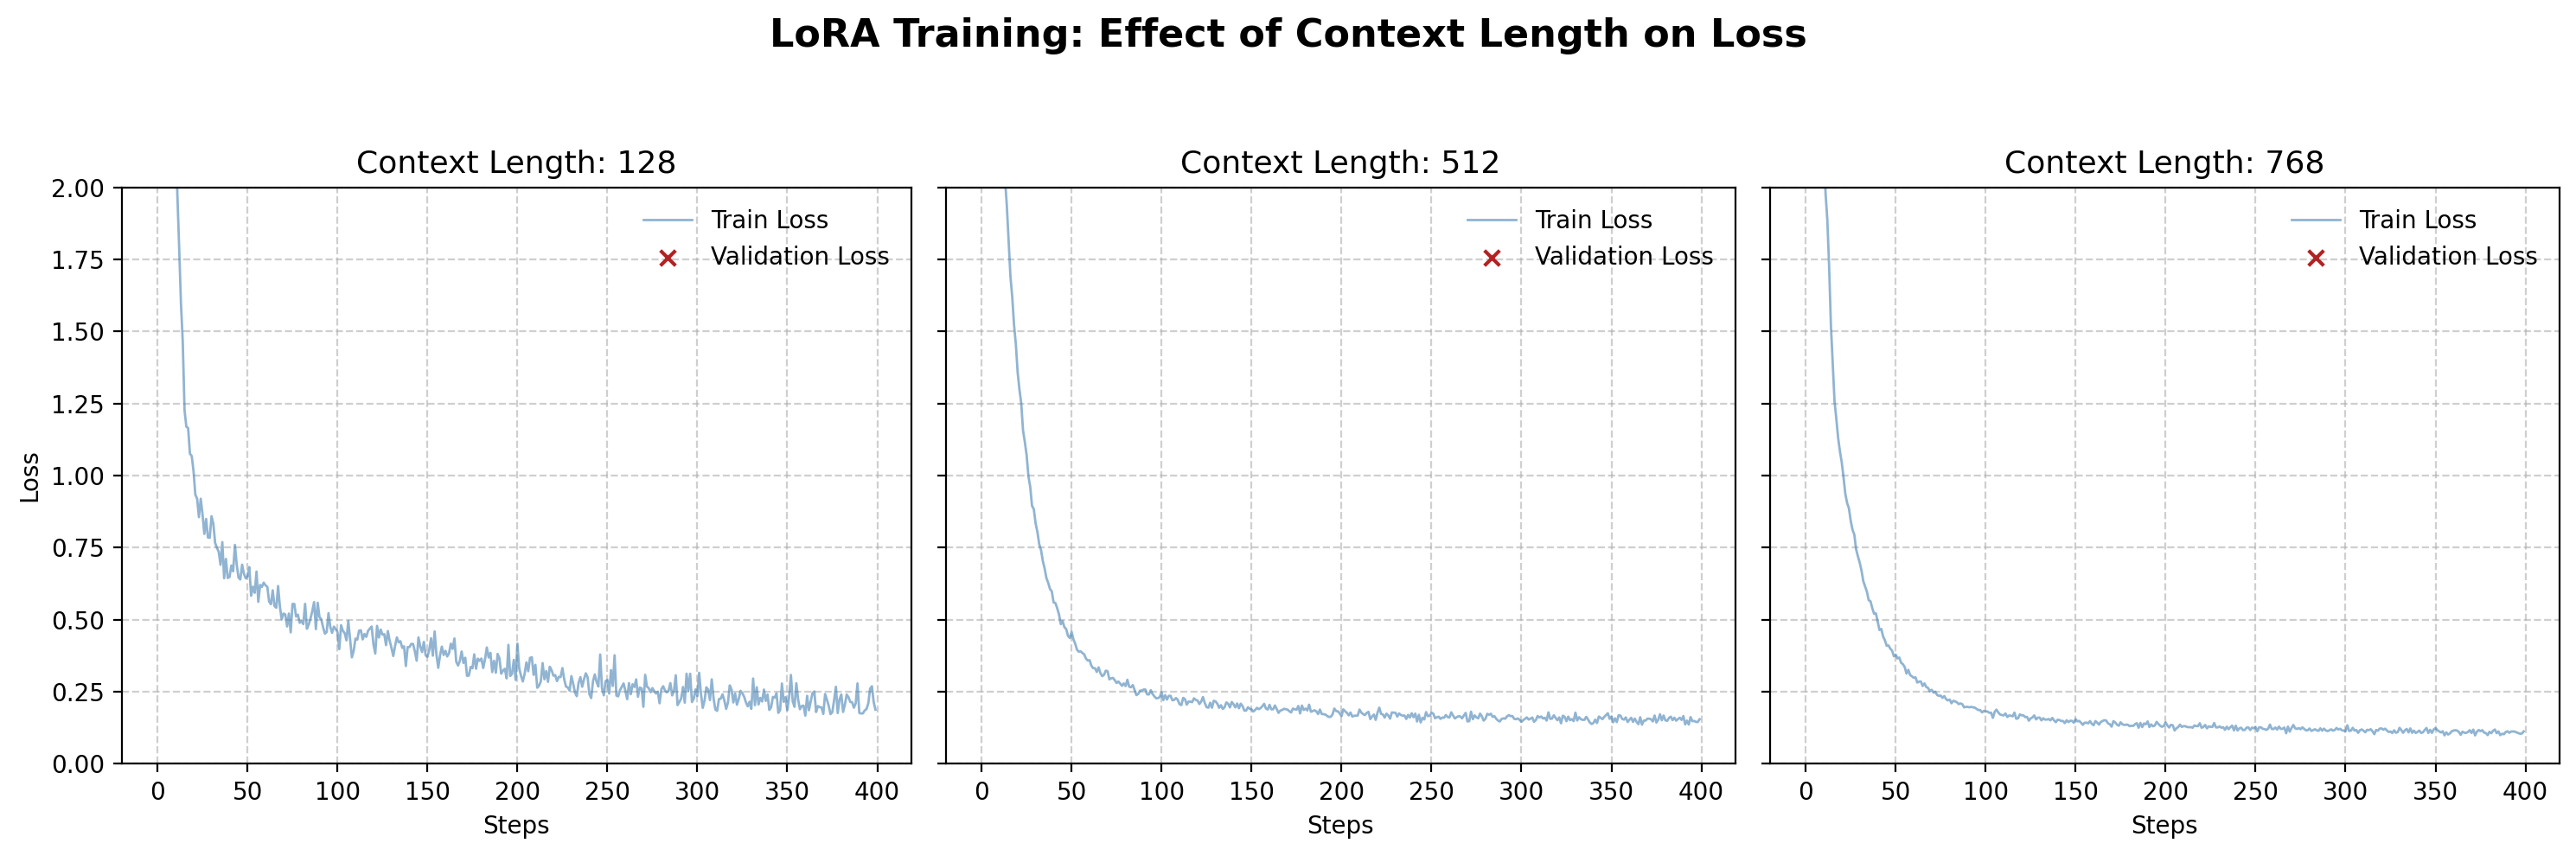

In [74]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ✅ Define Context Lengths
context_lengths = [128, 512, 768]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=200, sharey=True)
fig.suptitle("LoRA Training: Effect of Context Length on Loss", fontsize=16, fontweight='bold')

for i, ctx in enumerate(context_lengths):
    # Load losses
    train_losses = pd.read_csv(f"csv/train_loss_ctx{ctx}.csv")["train_loss"].values
    val_losses = pd.read_csv(f"csv/val_loss_ctx{ctx}.csv")["val_loss"].values
    val_steps = np.linspace(0, len(train_losses), len(val_losses))

    # Plot train loss
    axes[i].plot(train_losses, label="Train Loss", color="steelblue", linewidth=1, alpha=0.6)

    # Plot validation loss
    axes[i].scatter(val_steps, val_losses, label="Validation Loss", color="firebrick", marker="x", s=40)

    # Formatting
    axes[i].set_title(f"Context Length: {ctx}", fontsize=13)
    axes[i].set_xlabel("Steps")
    axes[i].set_ylim(0, 2)
    axes[i].grid(True, linestyle='--', alpha=0.6)
    axes[i].legend(frameon=False)

    if i == 0:
        axes[i].set_ylabel("Loss")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()



In [75]:
# Load all train loss CSVs and compute convergence speed
train_loss_files = glob.glob("csv/train_loss_ctx*.csv")
convergence_speeds = {f: compute_convergence_speed(f) for f in train_loss_files}

# Print results
for model, conv_speed in convergence_speeds.items():
    print(f"Model {model}: Converged at step {conv_speed}")

Model csv/train_loss_ctx512.csv: Converged at step 127
Model csv/train_loss_ctx128.csv: Converged at step 73
Model csv/train_loss_ctx768.csv: Converged at step 170


### Running Forecast for lots of IDS to build up table

In [ ]:
system_id = [800,820,840,860,880,900,920,940,960,980]  # System ID to sample
results = []

for system_id in system_id:
    # Step 1: Load the base model
    device = torch.device("cpu")
    model, tokenizer = load_qwen()  # Load base Qwen model
    model.to(device)

    # Step 2: Apply LoRA modifications (same as during training)
    lora_rank = 8
    for layer in model.model.layers:
        layer.self_attn.q_proj = LoRALinear(layer.self_attn.q_proj, r=lora_rank)
        layer.self_attn.v_proj = LoRALinear(layer.self_attn.v_proj, r=lora_rank)

    # Step 3: Load the LoRA-trained weights
    model.load_state_dict(torch.load("models/lora_qwen2.5_3c_4.pth", map_location="cpu"))

    # Step 4: Put model in evaluation mode
    model.eval()

    model.to(device)

    # Define parameters
    time_steps = 100
    forecast_horizon = 40 # Predict 1 time steps (10 values)
    history_length = time_steps - forecast_horizon  # Model sees 5 time steps (10 values)

    # Load and preprocess sample data
    preprocessor = LLMTIMEPreprocessor()
    sample_data = load_sample_data(system_id=system_id, time_steps=time_steps)  # Shape: (10,2)

    # Split into training and validation sets
    sample_data_train = sample_data[:history_length]  # (5,2) → 5 time steps
    sample_data_val = sample_data[history_length:history_length+forecast_horizon]  # (5,2) → 5 time steps

    # Preprocess (no flattening yet)
    preprocessed_seq = preprocessor.preprocess_sequence(sample_data_train)  
    tokenized_seq = preprocessor.tokenize_sequence(preprocessed_seq)

    # Convert tokenized sequence into tensor
    # input_ids = torch.tensor([tokenized_seq]).to(device)
    encoded_input = tokenizer(preprocessed_seq, return_tensors="pt", padding=True, truncation=True)
    input_ids = encoded_input["input_ids"].to(device)
    attention_mask = encoded_input["attention_mask"].to(device)

    # Generate extra tokens (to ensure enough numbers are extracted)
    with torch.no_grad():
        output = model.generate(
            input_ids,
            attention_mask=attention_mask,  #  Add attention mask
            max_new_tokens=6 * forecast_horizon * 2,
            min_length=forecast_horizon * 2,
        )

    # Decode model output
    decoded_output = tokenizer.decode(output[0], skip_special_tokens=True)

    # Extract numerical values from model output
    def extract_numerical_values(decoded_text):
        """Extract numerical values from model-generated text."""
        numeric_strings = decoded_text.replace(";", ",").split(",")  # Handle formatting
        print(" Raw Extracted Strings:", numeric_strings)
        return np.array([float(x) for x in numeric_strings[:-1]])

    # Extract numerical values (ensure exactly 10)
    predicted_values_full = extract_numerical_values(decoded_output) * 10

    start_index = len(sample_data_train.flatten())
    end_index = start_index + (forecast_horizon * 2)

    # Extract the correctly aligned predictions
    predicted_values = predicted_values_full[start_index:end_index]  

    # Ensure true values are correctly extracted
    true_values = sample_data_val.flatten()[:len(predicted_values)]  

    # Debugging prints
    # print(f"🔹 Training Ends at Index: {start_index}")
    # print(f"🔹 Extracting Predictions from {start_index} to {end_index}")
    # print(f"🔹 True Values Length: {len(true_values)}, Predicted Values Length: {len(predicted_values)}")


    # Debugging print statements
    # print(f'Length predicted_values_full: {len(predicted_values_full)}')
    # print(f'lenght of decoded_output: {len(decoded_output)}')
    # print(f'Length tokenized sequence: {len(tokenized_seq)}')
    # print(f'Length true values: {len(true_values)}')  # Should be 10
    # print(f'Length predicted values: {len(predicted_values)}')  # Should be 10

    # Evaluate predictions only if we got exactly 10 values
    if len(predicted_values) == forecast_horizon * 2:
        mse = mean_squared_error(true_values, predicted_values)
        mae = mean_absolute_error(true_values, predicted_values)
        r2 = r2_score(true_values, predicted_values)
    else:
        mse, mae, r2 = np.nan, np.nan, np.nan  # Model didn't generate valid predictions

    # Print results
    #print("\n🔹 Decoded Model Output:\n", decoded_output)
    #print("\n🔹 True Next 5 Values:\n", true_values)
    #print("\n🔹 Predicted Next 5 Values:\n", predicted_values)
    print(f"\n🔹 Evaluation Metrics:\nMSE: {mse:.5f} | MAE: {mae:.5f} | R² Score: {r2:.5f}")

    results.append({
    "system_id": system_id,
    "mse": mse,
    "mae": mae,
    "r2": r2
    })


results_df = pd.DataFrame(results)
results_df.to_csv("csv/forecast_eval_metrics.csv", index=False)
results_df.head()

KeyboardInterrupt: 

In [ ]:
system_id = [800,900,980]  # System ID to sample
results = []

for system_id in system_id:
    # Step 1: Load the base model
    device = torch.device("cpu")
    model, tokenizer = load_qwen()  # Load base Qwen model
    model.to(device)

    # Step 4: Put model in evaluation mode
    model.eval()
    model.to(device)

    # Define parameters
    time_steps = 100
    forecast_horizon = 40 # Predict 1 time steps (10 values)
    history_length = time_steps - forecast_horizon  # Model sees 5 time steps (10 values)

    # Load and preprocess sample data
    preprocessor = LLMTIMEPreprocessor()
    sample_data = load_sample_data(system_id=system_id, time_steps=time_steps)  # Shape: (10,2)

    # Split into training and validation sets
    sample_data_train = sample_data[:history_length]  # (5,2) → 5 time steps
    sample_data_val = sample_data[history_length:history_length+forecast_horizon]  # (5,2) → 5 time steps

    # Preprocess (no flattening yet)
    preprocessed_seq = preprocessor.preprocess_sequence(sample_data_train)  
    tokenized_seq = preprocessor.tokenize_sequence(preprocessed_seq)

    # Convert tokenized sequence into tensor
    # input_ids = torch.tensor([tokenized_seq]).to(device)
    encoded_input = tokenizer(preprocessed_seq, return_tensors="pt", padding=True, truncation=True)
    input_ids = encoded_input["input_ids"].to(device)
    attention_mask = encoded_input["attention_mask"].to(device)

    # Generate extra tokens (to ensure enough numbers are extracted)
    with torch.no_grad():
        output = model.generate(
            input_ids,
            attention_mask=attention_mask,  #  Add attention mask
            max_new_tokens=6 * forecast_horizon * 2,
            min_length=forecast_horizon * 2,
        )

    # Decode model output
    decoded_output = tokenizer.decode(output[0], skip_special_tokens=True)

    # Extract numerical values from model output
    def extract_numerical_values(decoded_text):
        """Extract numerical values from model-generated text."""
        numeric_strings = decoded_text.replace(";", ",").split(",")  # Handle formatting
        print("🧐 Raw Extracted Strings:", numeric_strings)
        return np.array([float(x) for x in numeric_strings[:-1]])

    # Extract numerical values (ensure exactly 10)
    predicted_values_full = extract_numerical_values(decoded_output) * 10

    start_index = len(sample_data_train.flatten())
    end_index = start_index + (forecast_horizon * 2)

    # Extract the correctly aligned predictions
    predicted_values = predicted_values_full[start_index:end_index]  

    # Ensure true values are correctly extracted
    true_values = sample_data_val.flatten()[:len(predicted_values)]  

    # Debugging prints
    # print(f"🔹 Training Ends at Index: {start_index}")
    # print(f"🔹 Extracting Predictions from {start_index} to {end_index}")
    # print(f"🔹 True Values Length: {len(true_values)}, Predicted Values Length: {len(predicted_values)}")


    # Debugging print statements
    # print(f'Length predicted_values_full: {len(predicted_values_full)}')
    # print(f'lenght of decoded_output: {len(decoded_output)}')
    # print(f'Length tokenized sequence: {len(tokenized_seq)}')
    # print(f'Length true values: {len(true_values)}')  # Should be 10
    # print(f'Length predicted values: {len(predicted_values)}')  # Should be 10

    # Evaluate predictions only if we got exactly 10 values
    if len(predicted_values) == forecast_horizon * 2:
        mse = mean_squared_error(true_values, predicted_values)
        mae = mean_absolute_error(true_values, predicted_values)
        r2 = r2_score(true_values, predicted_values)
    else:
        mse, mae, r2 = np.nan, np.nan, np.nan  # Model didn't generate valid predictions

    # Print results
    #print("\n🔹 Decoded Model Output:\n", decoded_output)
    #print("\n🔹 True Next 5 Values:\n", true_values)
    #print("\n🔹 Predicted Next 5 Values:\n", predicted_values)
    print(f"\n🔹 Evaluation Metrics:\nMSE: {mse:.5f} | MAE: {mae:.5f} | R² Score: {r2:.5f}")

    results.append({
    "system_id": system_id,
    "mse": mse,
    "mae": mae,
    "r2": r2
    })

results_df = pd.DataFrame(results)
results_df.to_csv("csv/forecast_eval_metrics_untrained.csv", index=False)
results_df.head()

🧐 Raw Extracted Strings: ['0.08', '0.11', '0.05', '0.09', '0.04', '0.07', '0.03', '0.05', '0.03', '0.04', '0.02', '0.03', '0.03', '0.02', '0.03', '0.02', '0.03', '0.01', '0.03', '0.01', '0.04', '0.01', '0.05', '0.01', '0.06', '0.0', '0.07', '0.0', '0.08', '0.0', '0.1', '0.0', '0.12', '0.0', '0.14', '0.0', '0.17', '0.0', '0.2', '0.0', '0.23', '0.0', '0.27', '0.01', '0.3', '0.01', '0.33', '0.02', '0.34', '0.03', '0.33', '0.05', '0.27', '0.07', '0.19', '0.1', '0.12', '0.11', '0.07', '0.1', '0.05', '0.08', '0.03', '0.06', '0.03', '0.05', '0.03', '0.04', '0.03', '0.03', '0.03', '0.02', '0.03', '0.02', '0.03', '0.01', '0.04', '0.01', '0.04', '0.01', '0.05', '0.01', '0.06', '0.0', '0.07', '0.0', '0.09', '0.0', '0.11', '0.0', '0.13', '0.0', '0.15', '0.0', '0.18', '0.0', '0.21', '0.0', '0.25', '0.01', '0.28', '0.01', '0.31', '0.01', '0.34', '0.02', '0.34', '0.04', '0.3', '0.06', '0.23', '0.09', '0.15', '0.1', '0.09', '0.1', '0.06', '0.09', '0.04', '0.07', '0.03', '0.05', '0.03', '0.04', '0.03',

,system_id,mse,mae,r2
0,800,0.006310,0.057112,0.990438
1,900,0.209223,0.375343,-2.026335
2,980,0.401611,0.492592,-0.978689


## FORECASTS

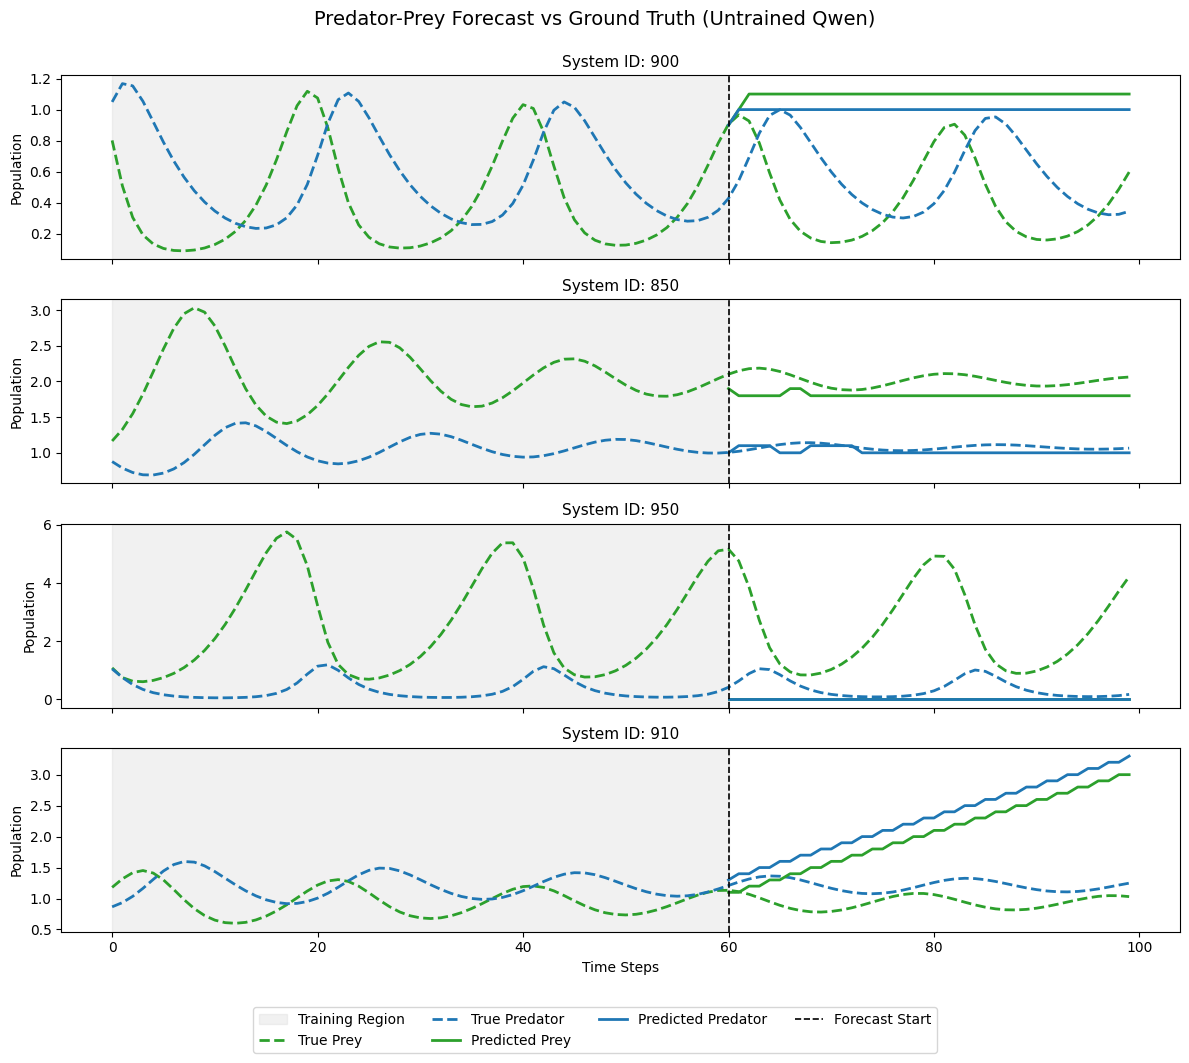

In [ ]:
# --- Load model and tokenizer (Untrained)
model, tokenizer = load_qwen()
model.eval()

# --- Load data
preprocessor = LLMTIMEPreprocessor()
trajectories = h5py.File("lotka_volterra_data.h5", "r")["trajectories"][:]

true_predator_color = '#1f77b4'
pred_predator_color = '#1f77b4'
true_prey_color = '#2ca02c'
pred_prey_color = '#2ca02c'

SYSTEM_IDS = [900, 920, 940, 950]
TIME_STEPS = 100
SPLIT_POINT = 60
SCALE_FACTOR = 10
NUM_RUNS_UNTRAINED = 1

def parse_decoded_output(decoded_str, scale_factor=10):
    try:
        parsed_data = np.array([
            list(map(float, pair.split(",")))
            for pair in decoded_str.split(";") if "," in pair
        ])
        return parsed_data[:40] * scale_factor if parsed_data.shape[0] >= 40 else np.zeros((40, 2))
    except ValueError:
        return np.zeros((40, 2))

def run_prediction(model, tokenizer, input_tensor, num_runs):
    model.eval()
    predictions = []
    attention_mask = (input_tensor != tokenizer.pad_token_id).long()

    with torch.no_grad():
        for _ in range(num_runs):
            output_tokens = model.generate(input_tensor, attention_mask=attention_mask, max_new_tokens=1100, min_length=1000)
            generated_tokens = output_tokens[0].tolist()[len(input_tensor[0]):]
            decoded_output = tokenizer.decode(generated_tokens, skip_special_tokens=True)
            prediction = parse_decoded_output(decoded_output)
            predictions.append(prediction)
    predictions = np.array(predictions)
    return np.mean(predictions, axis=0) if num_runs > 1 else predictions[0]

# --- 4x1 Grid Plot (Consistent styling)
fig, axs = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
axs = axs.flatten()

for idx, system_id in enumerate(SYSTEM_IDS):
    sequence = trajectories[system_id, :, :]
    input_sequence = sequence[:SPLIT_POINT]
    true_output_sequence = sequence[SPLIT_POINT:]

    preprocessed_input = preprocessor.preprocess_sequence(input_sequence)
    tokenized_input = preprocessor.tokenize_sequence(preprocessed_input)
    input_tensor = torch.tensor([tokenized_input]).to(model.device)

    prediction = run_prediction(model, tokenizer, input_tensor, NUM_RUNS_UNTRAINED)

    ax = axs[idx]
    # Shade training region
    ax.axvspan(0, SPLIT_POINT, color='lightgrey', alpha=0.3, label="Training Region" if idx == 0 else None)

    # True values
    ax.plot(range(TIME_STEPS), sequence[:, 0], label="True Prey", linestyle="--", color="#2ca02c", linewidth=2)
    ax.plot(range(TIME_STEPS), sequence[:, 1], label="True Predator", linestyle="--", color="#1f77b4", linewidth=2)

    # Predictions
    forecast_range = range(SPLIT_POINT, SPLIT_POINT + len(prediction))
    ax.plot(forecast_range, prediction[:, 0], label="Predicted Prey", linestyle="-", color="#2ca02c", linewidth=2)
    ax.plot(forecast_range, prediction[:, 1], label="Predicted Predator", linestyle="-", color="#1f77b4", linewidth=2)

    # Forecast start
    ax.axvline(x=SPLIT_POINT, color='black', linestyle='--', lw=1.2, label="Forecast Start" if idx == 0 else None)

    ax.set_title(f"System ID: {system_id}", fontsize=11)
    ax.set_ylabel("Population")

axs[-1].set_xlabel("Time Steps")

# Shared legend
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.02), fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.suptitle("Predator-Prey Forecast vs Ground Truth (Untrained Qwen)", fontsize=14, y=1.03)

plt.savefig("untrained_qwen_4x1_grid.png", dpi=300, bbox_inches='tight')
plt.show()

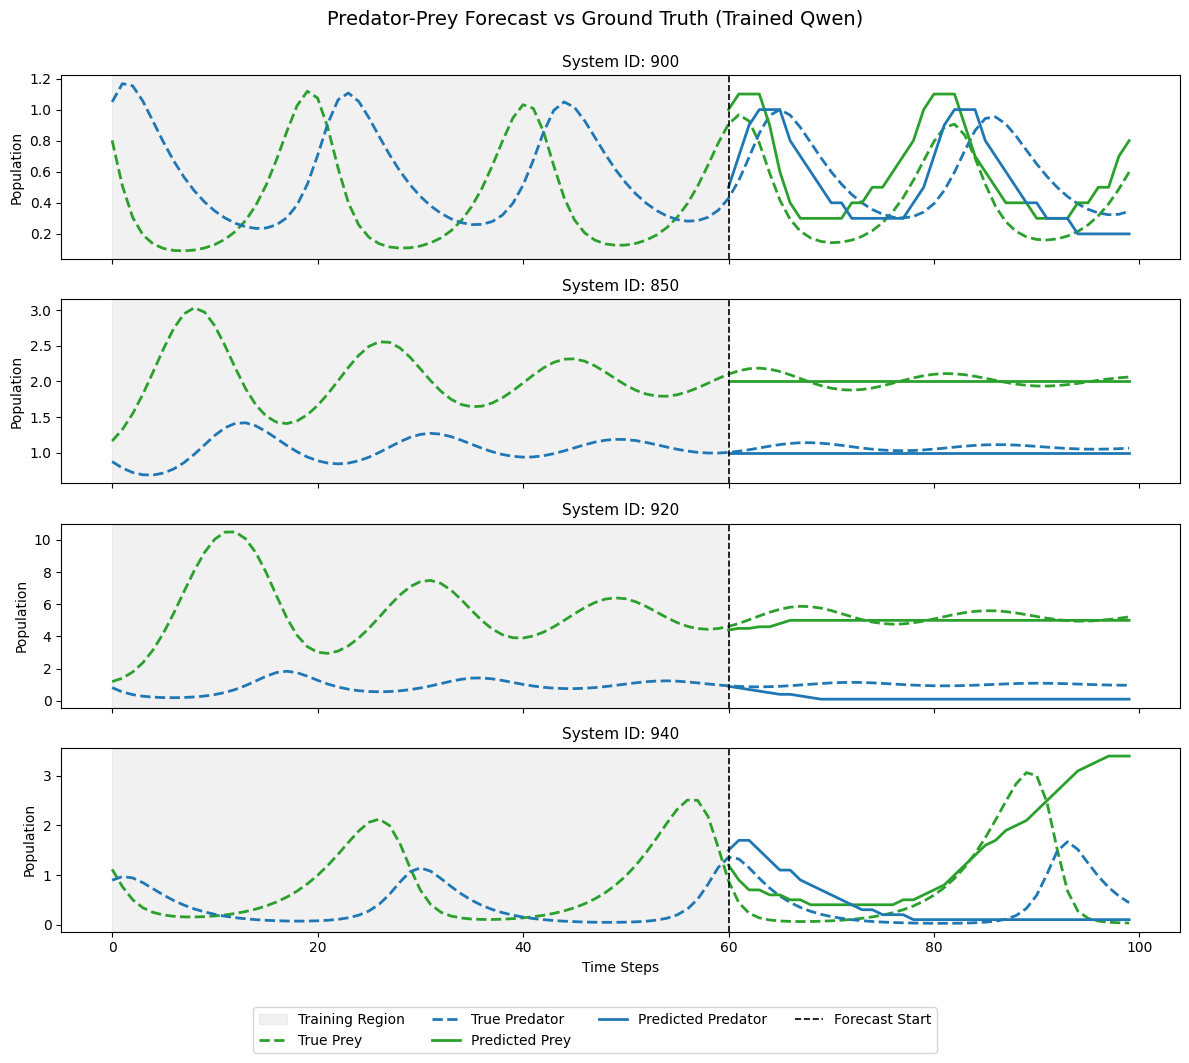

In [ ]:
# --- Load model and tokenizer (Untrained)

device = torch.device("cpu")
model, tokenizer = load_qwen()
model.to(device)

# Inject LoRA layers
lora_rank = 4
for layer in model.model.layers:
    layer.self_attn.q_proj = LoRALinear(layer.self_attn.q_proj, r=lora_rank)
    layer.self_attn.v_proj = LoRALinear(layer.self_attn.v_proj, r=lora_rank)

# Load trained LoRA weights
model.load_state_dict(torch.load("models/lora_qwen2.5_final_5000.pth", map_location="cpu"), strict=False)
model.eval()

# --- Load data
preprocessor = LLMTIMEPreprocessor()
trajectories = h5py.File("lotka_volterra_data.h5", "r")["trajectories"][:]

true_predator_color = '#1f77b4'
pred_predator_color = '#1f77b4'
true_prey_color = '#2ca02c'
pred_prey_color = '#2ca02c'

SYSTEM_IDS = [900, 920, 940, 950]
TIME_STEPS = 100
SPLIT_POINT = 60
SCALE_FACTOR = 10

def parse_decoded_output(decoded_str, scale_factor=10):
    try:
        parsed_data = np.array([
            list(map(float, pair.split(",")))
            for pair in decoded_str.split(";") if "," in pair
        ])
        return parsed_data[:40] * scale_factor if parsed_data.shape[0] >= 40 else np.zeros((40, 2))
    except ValueError:
        return np.zeros((40, 2))

def run_prediction(model, tokenizer, input_tensor, num_runs):
    model.eval()
    predictions = []
    attention_mask = (input_tensor != tokenizer.pad_token_id).long()

    with torch.no_grad():
        for _ in range(num_runs):
            output_tokens = model.generate(input_tensor, attention_mask=attention_mask, max_new_tokens=1100, min_length=1000)
            generated_tokens = output_tokens[0].tolist()[len(input_tensor[0]):]
            decoded_output = tokenizer.decode(generated_tokens, skip_special_tokens=True)
            prediction = parse_decoded_output(decoded_output)
            predictions.append(prediction)
    predictions = np.array(predictions)
    return np.mean(predictions, axis=0) if num_runs > 1 else predictions[0]

# --- 4x1 Grid Plot (Consistent styling)
fig, axs = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
axs = axs.flatten()

for idx, system_id in enumerate(SYSTEM_IDS):
    sequence = trajectories[system_id, :, :]
    input_sequence = sequence[:SPLIT_POINT]
    true_output_sequence = sequence[SPLIT_POINT:]

    preprocessed_input = preprocessor.preprocess_sequence(input_sequence)
    tokenized_input = preprocessor.tokenize_sequence(preprocessed_input)
    input_tensor = torch.tensor([tokenized_input]).to(model.device)

    prediction = run_prediction(model, tokenizer, input_tensor, 1)

    ax = axs[idx]
    # Shade training region
    ax.axvspan(0, SPLIT_POINT, color='lightgrey', alpha=0.3, label="Training Region" if idx == 0 else None)

    # True values
    ax.plot(range(TIME_STEPS), sequence[:, 0], label="True Prey", linestyle="--", color="#2ca02c", linewidth=2)
    ax.plot(range(TIME_STEPS), sequence[:, 1], label="True Predator", linestyle="--", color="#1f77b4", linewidth=2)

    # Predictions
    forecast_range = range(SPLIT_POINT, SPLIT_POINT + len(prediction))
    ax.plot(forecast_range, prediction[:, 0], label="Predicted Prey", linestyle="-", color="#2ca02c", linewidth=2)
    ax.plot(forecast_range, prediction[:, 1], label="Predicted Predator", linestyle="-", color="#1f77b4", linewidth=2)

    # Forecast start
    ax.axvline(x=SPLIT_POINT, color='black', linestyle='--', lw=1.2, label="Forecast Start" if idx == 0 else None)

    ax.set_title(f"System ID: {system_id}", fontsize=11)
    ax.set_ylabel("Population")

axs[-1].set_xlabel("Time Steps")

# Shared legend
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.02), fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.suptitle("Predator-Prey Forecast vs Ground Truth (Trained Qwen)", fontsize=14, y=1.03)

plt.savefig("trained_forecast_5000.png", dpi=300, bbox_inches='tight')
plt.show()

## MSE/MAE/R^2/FLOPS 

### Untrained

In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd

# --- Store results
metrics = {
    "System ID": [],
    "MSE": [],
    "MAE": [],
    "R2 Score": []
}

for system_id in SYSTEM_IDS:
    # Load sequence and run forecast
    sequence = trajectories[system_id, :, :]
    input_sequence = sequence[:SPLIT_POINT]
    true_output_sequence = sequence[SPLIT_POINT:]

    preprocessed_input = preprocessor.preprocess_sequence(input_sequence)
    tokenized_input = preprocessor.tokenize_sequence(preprocessed_input)
    input_tensor = torch.tensor([tokenized_input]).to(model.device)

    prediction = run_prediction(model, tokenizer, input_tensor, NUM_RUNS_UNTRAINED)

    # Clip length to match in case decoded output is shorter
    n_pred = min(len(true_output_sequence), len(prediction))
    y_true = true_output_sequence[:n_pred].flatten()
    y_pred = prediction[:n_pred].flatten()

    # Compute metrics
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    metrics["System ID"].append(system_id)
    metrics["MSE"].append(mse)
    metrics["MAE"].append(mae)
    metrics["R2 Score"].append(r2)

# --- Convert to DataFrame and display
metrics_df = pd.DataFrame(metrics)
print(metrics_df)

# Optional: Save to CSV
metrics_df.to_csv("csv/forecast_metrics_untrained.csv", index=False)


   System ID       MSE       MAE  R2 Score
0        900  0.025544  0.133818  0.630512
1        850  0.007461  0.075628  0.967205
2        920  3.667437  1.619250  0.191227
3        940  0.886076  0.802603 -0.547397


### Trained

In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd

# --- Store results
metrics = {
    "System ID": [],
    "MSE": [],
    "MAE": [],
    "R2 Score": []
}

device = torch.device("cpu")
model, tokenizer = load_qwen()
model.to(device)

# Inject LoRA layers
lora_rank = 4
for layer in model.model.layers:
    layer.self_attn.q_proj = LoRALinear(layer.self_attn.q_proj, r=lora_rank)
    layer.self_attn.v_proj = LoRALinear(layer.self_attn.v_proj, r=lora_rank)

# Load trained LoRA weights
model.load_state_dict(torch.load("models/lora_qwen2.5_final_5000.pth", map_location="cpu"), strict=False)
model.eval()


for system_id in SYSTEM_IDS:
    # Load sequence and run forecast
    sequence = trajectories[system_id, :, :]
    input_sequence = sequence[:SPLIT_POINT]
    true_output_sequence = sequence[SPLIT_POINT:]

    preprocessed_input = preprocessor.preprocess_sequence(input_sequence)
    tokenized_input = preprocessor.tokenize_sequence(preprocessed_input)
    input_tensor = torch.tensor([tokenized_input]).to(model.device)

    prediction = run_prediction(model, tokenizer, input_tensor, NUM_RUNS_UNTRAINED)

    # Clip length to match in case decoded output is shorter
    n_pred = min(len(true_output_sequence), len(prediction))
    y_true = true_output_sequence[:n_pred].flatten()
    y_pred = prediction[:n_pred].flatten()

    # Compute metrics
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    metrics["System ID"].append(system_id)
    metrics["MSE"].append(mse)
    metrics["MAE"].append(mae)
    metrics["R2 Score"].append(r2)

# --- Convert to DataFrame and display
metrics_df = pd.DataFrame(metrics)
print(metrics_df)

# Optional: Save to CSV
metrics_df.to_csv("csv/forecast_metrics_trained_5000.csv", index=False)


   System ID       MSE       MAE  R2 Score
0        900  0.276426  0.375842 -2.998392
1        850  0.007461  0.075628  0.967205
2        920  4.094470  1.661750  0.097054
3        940  1.170846  0.767191 -1.044704
